# 🏆 Datathon 2026 — The Gridbreaker
## Part 2: Data Visualization & Analysis
### "NGỪNG RÒ RỈ: Giải Phẫu Thất Thoát Lợi Nhuận Trong TMĐT Thời Trang Việt Nam"

**Narrative arc:** Problem Statement → Integrity Check → Descriptive → Diagnostic → Predictive (R²=0.772) → Prescriptive

---

## MODULE 0 — Data Loading & Integrity Check

In [1]:
# ============================================================
# MODULE 0A: GLOBAL SETUP & CSV LOADING
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)

# ── PALETTE (Cohesive color system xuyên suốt báo cáo) ──────
PALETTE = {
    'profit'   : '#2ECC71',   # xanh lá  — vùng có lời
    'loss'     : '#E74C3C',   # đỏ       — vùng lỗ
    'neutral'  : '#95A5A6',   # xám      — nền/trung tính
    'accent'   : '#2C3E50',   # navy     — tiêu đề / nhấn
    'warning'  : '#F39C12',   # cam      — cảnh báo
    'bg'       : '#F8F9FA',   # trắng xám — nền chart
    'cat1'     : '#3498DB',
    'cat2'     : '#9B59B6',
    'cat3'     : '#1ABC9C',
    'cat4'     : '#E67E22',
}

plt.rcParams.update({
    'figure.facecolor' : PALETTE['bg'],
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
})

DATA_PATH = "../dataset/"   # ← Set to your data directory path

# ── LOAD ALL CSVs ───────────────────────────────────────────
print("=" * 60)
print("LOADING ALL CSV FILES")
print("=" * 60)

files = {
    'products'   : 'products.csv',
    'customers'  : 'customers.csv',
    'promotions' : 'promotions.csv',
    'geography'  : 'geography.csv',
    'orders'     : 'orders.csv',
    'order_items': 'order_items.csv',
    'payments'   : 'payments.csv',
    'shipments'  : 'shipments.csv',
    'returns'    : 'returns.csv',
    'reviews'    : 'reviews.csv',
    'sales'      : 'sales.csv',
    'inventory'  : 'inventory.csv',
    'web_traffic': 'web_traffic.csv',
}

dfs = {}
for name, fname in files.items():
    try:
        df = pd.read_csv(DATA_PATH + fname)
        dfs[name] = df
        print(f"  ✅  {name:<15} → {df.shape[0]:>8,} rows × {df.shape[1]:>2} cols")
    except FileNotFoundError:
        print(f"  ❌  {name:<15} → FILE NOT FOUND: {fname}")

# ── DATE PARSING ────────────────────────────────────────────
date_cols = {
    'orders'     : ['order_date'],
    'shipments'  : ['ship_date', 'delivery_date'],
    'returns'    : ['return_date'],
    'reviews'    : ['review_date'],
    'promotions' : ['start_date', 'end_date'],
    'customers'  : ['signup_date'],
    'inventory'  : ['snapshot_date'],
    'web_traffic': ['date'],
    'sales'      : ['Date'],
}
for tbl, cols in date_cols.items():
    if tbl in dfs:
        for c in cols:
            if c in dfs[tbl].columns:
                dfs[tbl][c] = pd.to_datetime(dfs[tbl][c])

print("\n✅ Date columns parsed.")

LOADING ALL CSV FILES
  ✅  products        →    2,412 rows ×  8 cols
  ✅  customers       →  121,930 rows ×  7 cols
  ✅  promotions      →       50 rows × 10 cols
  ✅  geography       →   39,948 rows ×  4 cols
  ✅  orders          →  646,945 rows ×  8 cols
  ✅  order_items     →  714,669 rows ×  7 cols
  ✅  payments        →  646,945 rows ×  4 cols
  ✅  shipments       →  566,067 rows ×  4 cols
  ✅  returns         →   39,939 rows ×  7 cols
  ✅  reviews         →  113,551 rows ×  7 cols
  ✅  sales           →    3,833 rows ×  3 cols
  ✅  inventory       →   60,247 rows × 17 cols
  ✅  web_traffic     →    3,652 rows ×  7 cols

✅ Date columns parsed.


In [2]:
# ============================================================
# MODULE 0B: GRAIN VERIFICATION & FK INTEGRITY
# ============================================================
print("=" * 60)
print("GRAIN VERIFICATION")
print("=" * 60)

grain_checks = {
    'products'   : ['product_id'],
    'customers'  : ['customer_id'],
    'promotions' : ['promo_id'],
    'geography'  : ['zip'],
    'orders'     : ['order_id'],
    'order_items': ['order_id', 'product_id'],
    'payments'   : ['order_id'],
    'returns'    : ['return_id'],
    'reviews'    : ['review_id'],
    'inventory'  : ['snapshot_date', 'product_id'],
    'web_traffic': ['date', 'traffic_source'],
}
for tbl, keys in grain_checks.items():
    if tbl not in dfs:
        continue
    df = dfs[tbl]
    n_rows, n_unique = len(df), df[keys].drop_duplicates().shape[0]
    status = "✅ UNIQUE" if n_unique == n_rows else f"⚠️  DUPLICATES ({n_rows - n_unique:,} extra)"
    print(f"  {tbl:<15} | PK: {keys} → {status}")

# ── FOREIGN KEY CHECK ────────────────────────────────────────
print("\n" + "=" * 60)
print("FOREIGN KEY INTEGRITY")
print("=" * 60)

def fk_check(child_df, child_col, parent_df, parent_col, child_name, parent_name):
    orphans = set(child_df[child_col].dropna().unique()) - set(parent_df[parent_col].dropna().unique())
    pct = (1 - len(orphans) / max(len(set(child_df[child_col].dropna().unique())), 1)) * 100
    status = "✅" if len(orphans) == 0 else f"⚠️  {len(orphans):,} orphan keys"
    print(f"  {child_name}.{child_col} → {parent_name}.{parent_col} | {status} | Coverage: {pct:.1f}%")

fk_check(dfs['order_items'], 'order_id',    dfs['orders'],    'order_id',    'order_items', 'orders')
fk_check(dfs['order_items'], 'product_id',  dfs['products'],  'product_id',  'order_items', 'products')
fk_check(dfs['orders'],      'customer_id', dfs['customers'], 'customer_id', 'orders',      'customers')
fk_check(dfs['orders'],      'zip',         dfs['geography'], 'zip',         'orders',      'geography')
fk_check(dfs['returns'],     'order_id',    dfs['orders'],    'order_id',    'returns',     'orders')
fk_check(dfs['reviews'],     'order_id',    dfs['orders'],    'order_id',    'reviews',     'orders')

# ── CRITICAL ANOMALY CHECK ───────────────────────────────────
print("\n" + "=" * 60)
print("CRITICAL ANOMALY CHECKS")
print("=" * 60)

oi_check = dfs['order_items'].merge(dfs['products'][['product_id','price','cogs']], on='product_id', how='left')
n_below_cogs = (oi_check['unit_price'] < oi_check['cogs']).sum()
n_exact_match = (oi_check['unit_price'] == oi_check['price']).sum()
n_lower = (oi_check['unit_price'] < oi_check['price']).sum()
n_higher = (oi_check['unit_price'] > oi_check['price']).sum()

print(f"\n  [A] unit_price < cogs (pre-discount loss): {n_below_cogs:>8,} rows ({n_below_cogs/len(oi_check)*100:.1f}%)")
print(f"  [B] unit_price == products.price          : {n_exact_match:>8,} rows ({n_exact_match/len(oi_check)*100:.1f}%)")
print(f"  [C] unit_price < products.price           : {n_lower:>8,} rows ({n_lower/len(oi_check)*100:.1f}%)")
print(f"  [D] unit_price > products.price           : {n_higher:>8,} rows ({n_higher/len(oi_check)*100:.1f}%)")

# Promo stack distribution
oi_raw = dfs['order_items']
n_no   = oi_raw['promo_id'].isna().sum()
n_one  = (oi_raw['promo_id'].notna() & oi_raw['promo_id_2'].isna()).sum()
n_two  = (oi_raw['promo_id'].notna() & oi_raw['promo_id_2'].notna()).sum()
print(f"\n  [H] Promo distribution:")
print(f"      No promo        : {n_no:>8,} ({n_no/len(oi_raw)*100:.1f}%)")
print(f"      1 promo         : {n_one:>8,} ({n_one/len(oi_raw)*100:.1f}%)")
print(f"      2 promos (stack): {n_two:>8,} ({n_two/len(oi_raw)*100:.1f}%)")

print("\n✅ MODULE 0 COMPLETE — 6/6 FK relationships: 100% coverage. Data issues = business governance failures, not data artifacts.")

GRAIN VERIFICATION
  products        | PK: ['product_id'] → ✅ UNIQUE
  customers       | PK: ['customer_id'] → ✅ UNIQUE
  promotions      | PK: ['promo_id'] → ✅ UNIQUE
  geography       | PK: ['zip'] → ✅ UNIQUE
  orders          | PK: ['order_id'] → ✅ UNIQUE
  order_items     | PK: ['order_id', 'product_id'] → ⚠️  DUPLICATES (16 extra)
  payments        | PK: ['order_id'] → ✅ UNIQUE
  returns         | PK: ['return_id'] → ✅ UNIQUE
  reviews         | PK: ['review_id'] → ✅ UNIQUE
  inventory       | PK: ['snapshot_date', 'product_id'] → ✅ UNIQUE
  web_traffic     | PK: ['date', 'traffic_source'] → ✅ UNIQUE

FOREIGN KEY INTEGRITY
  order_items.order_id → orders.order_id | ✅ | Coverage: 100.0%
  order_items.product_id → products.product_id | ✅ | Coverage: 100.0%
  orders.customer_id → customers.customer_id | ✅ | Coverage: 100.0%
  orders.zip → geography.zip | ✅ | Coverage: 100.0%
  returns.order_id → orders.order_id | ✅ | Coverage: 100.0%
  reviews.order_id → orders.order_id | ✅ | Coverag

## MODULE 1 — Margin Engineering & Descriptive Analysis

In [3]:
# ============================================================
# MODULE 1A: DEDUP + JOIN + MARGIN ENGINEERING
# ============================================================
print("STEP 1: Dedup order_items (16 duplicate grain rows)...")

oi_raw = dfs['order_items'].copy()
oi = (oi_raw
      .groupby(['order_id', 'product_id'], as_index=False)
      .agg(
          quantity        = ('quantity',        'sum'),
          unit_price      = ('unit_price',      'first'),
          discount_amount = ('discount_amount', 'sum'),
          promo_id        = ('promo_id',        'first'),
          promo_id_2      = ('promo_id_2',      'first'),
      ))
print(f"  After dedup: {len(oi_raw):,} → {len(oi):,} rows")

# ── Join products (cogs, category, segment) ──────────────────
products = dfs['products'][['product_id','price','cogs','category','segment','size']].copy()
oi = oi.merge(products, on='product_id', how='left')

# ── Join orders (date, status, source) ───────────────────────
orders_meta = dfs['orders'][['order_id','order_date','order_status','payment_method','order_source']].copy()
oi = oi.merge(orders_meta, on='order_id', how='left')
oi['year']    = oi['order_date'].dt.year
oi['quarter'] = oi['order_date'].dt.to_period('Q').astype(str)
oi['month']   = oi['order_date'].dt.to_period('M').astype(str)
oi['qtr']     = oi['order_date'].dt.quarter
oi['order_ym']= oi['order_date'].dt.to_period('M')

print(f"\nSTEP 2: Margin engineering...")

# ── MARGIN FORMULA ───────────────────────────────────────────
# unit_discount  = discount_amount / quantity
# margin         = unit_price - unit_discount - cogs
# margin_ratio   = margin / unit_price × 100
# line_margin    = margin × quantity
oi['unit_discount']  = oi['discount_amount'] / oi['quantity']
oi['net_unit_price'] = oi['unit_price'] - oi['unit_discount']
oi['margin']         = oi['unit_price'] - oi['unit_discount'] - oi['cogs']
oi['margin_ratio']   = (oi['margin'] / oi['unit_price'].replace(0, np.nan)) * 100
oi['line_margin']    = oi['margin'] * oi['quantity']
oi['line_revenue']   = oi['unit_price'] * oi['quantity'] - oi['discount_amount']
oi['price_gap']      = oi['cogs'] - oi['unit_price']  # positive = selling below cost

# ── MARGIN HEALTH CLASSIFICATION ────────────────────────────
def classify_margin(row):
    if row['margin'] < 0:
        return 'Lỗ_Giá_Gốc' if row['unit_price'] < row['cogs'] else 'Lỗ_Do_Discount'
    return 'Biên_Mỏng' if row['margin_ratio'] < 10 else 'Khỏe_Mạnh'

oi['margin_class'] = oi.apply(classify_margin, axis=1)

# ── PROMO GROUP LABEL ────────────────────────────────────────
oi['promo_group'] = 'Không KM'
oi.loc[oi['promo_id'].notna() & oi['promo_id_2'].isna(),  'promo_group'] = '1 KM'
oi.loc[oi['promo_id'].notna() & oi['promo_id_2'].notna(), 'promo_group'] = '2 KM (Stacked)'

# ── SUMMARY ──────────────────────────────────────────────────
total_loss = oi.loc[oi['line_margin'] < 0, 'line_margin'].sum()
total_rev  = oi['line_revenue'].sum()
actual_gp  = oi['line_margin'].sum()
potential_gp = oi[oi['line_margin'] > 0]['line_margin'].sum()

print("\n" + "=" * 60)
print("MARGIN HEALTH SUMMARY (2013–2022)")
print("=" * 60)
summary = (oi.groupby('margin_class')
             .agg(rows=('order_id','count'), total_margin=('line_margin','sum'))
             .assign(pct_rows=lambda x: x['rows']/x['rows'].sum()*100)
             .sort_values('total_margin'))
print(summary.round(0).to_string())
print(f"\n  💰 Tổng tiền lỗ tuyệt đối  : {abs(total_loss)/1e9:.3f} tỷ VND")
print(f"  💹 Gross profit tiềm năng   : {potential_gp/1e9:.3f} tỷ VND")
print(f"  📊 Gross profit thực tế     : {actual_gp/1e9:.3f} tỷ VND")
print(f"  🔴 Thất thoát               : {abs(total_loss)/potential_gp*100:.1f}% giá trị tiềm năng bị xóa sổ")

STEP 1: Dedup order_items (16 duplicate grain rows)...
  After dedup: 714,669 → 714,653 rows

STEP 2: Margin engineering...

MARGIN HEALTH SUMMARY (2013–2022)
                  rows       total_margin  pct_rows
margin_class                                       
Lỗ_Giá_Gốc      133050  -833,809,519.0000   19.0000
Lỗ_Do_Discount   58310   -81,710,073.0000    8.0000
Biên_Mỏng       189611   256,747,753.0000   27.0000
Khỏe_Mạnh       333682 2,176,189,760.0000   47.0000

  💰 Tổng tiền lỗ tuyệt đối  : 0.916 tỷ VND
  💹 Gross profit tiềm năng   : 2.433 tỷ VND
  📊 Gross profit thực tế     : 1.517 tỷ VND
  🔴 Thất thoát               : 37.6% giá trị tiềm năng bị xóa sổ


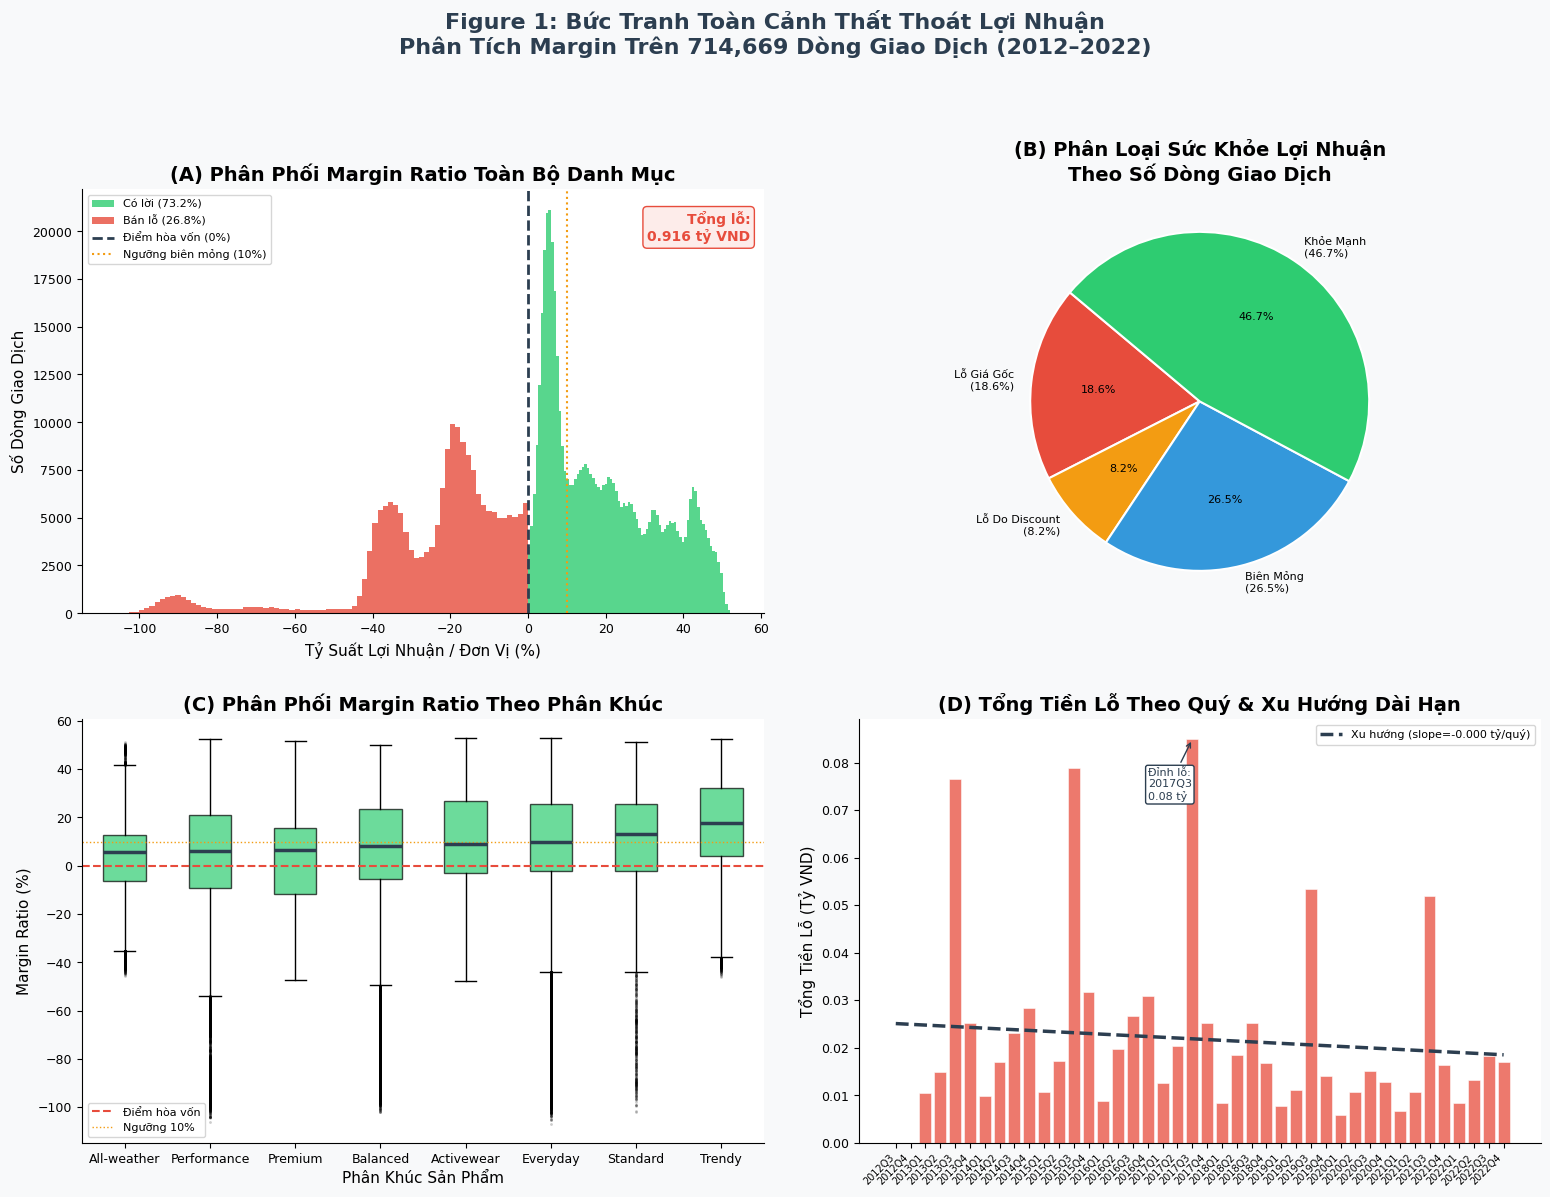

✅ Figure 1 saved.

Caption: Trên 714,669 dòng giao dịch, 26.78% bán lỗ (tổng 915.5M VND). Layer 1 (unit_price < cogs)
chiếm 18.62% / 133,050 dòng — nặng hơn 10× so với Layer 2. Q3 là đỉnh lỗ định kỳ.


In [4]:
# ============================================================
# MODULE 1B: FIGURE 1 — BỨC TRANH TOÀN CẢNH THẤT THOÁT
# ============================================================
quarterly_loss = (oi[oi['line_margin'] < 0]
                  .groupby('quarter')['line_margin']
                  .sum().reset_index())
quarterly_loss['loss_bn'] = quarterly_loss['line_margin'].abs() / 1e9

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Figure 1: Bức Tranh Toàn Cảnh Thất Thoát Lợi Nhuận\n'
    'Phân Tích Margin Trên 714,669 Dòng Giao Dịch (2012–2022)',
    fontsize=16, fontweight='bold', color=PALETTE['accent'], y=1.01
)

# Panel A: Histogram margin_ratio distribution
ax = axes[0, 0]
clip = oi['margin_ratio'].clip(-150, 100)
ax.hist(clip[clip >= 0], bins=80, color=PALETTE['profit'], alpha=0.8,
        label=f'Có lời ({(oi["margin_ratio"]>=0).mean()*100:.1f}%)')
ax.hist(clip[clip < 0],  bins=80, color=PALETTE['loss'],   alpha=0.8,
        label=f'Bán lỗ ({(oi["margin_ratio"]<0).mean()*100:.1f}%)')
ax.axvline(0,  color=PALETTE['accent'],  lw=2,   ls='--', label='Điểm hòa vốn (0%)')
ax.axvline(10, color=PALETTE['warning'], lw=1.5, ls=':', label='Ngưỡng biên mỏng (10%)')
ax.set_xlabel('Tỷ Suất Lợi Nhuận / Đơn Vị (%)')
ax.set_ylabel('Số Dòng Giao Dịch')
ax.set_title('(A) Phân Phối Margin Ratio Toàn Bộ Danh Mục')
ax.legend(fontsize=8)
ax.text(0.98, 0.95, f'Tổng lỗ:\n{abs(total_loss/1e9):.3f} tỷ VND',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        color=PALETTE['loss'], fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FDECEA', edgecolor=PALETTE['loss']))

# Panel B: Pie chart margin classes
ax = axes[0, 1]
ordered_classes = ['Lỗ_Giá_Gốc', 'Lỗ_Do_Discount', 'Biên_Mỏng', 'Khỏe_Mạnh']
class_counts = oi['margin_class'].value_counts()
pie_vals = [class_counts.get(c, 0) for c in ordered_classes]
pie_lbls = [f"{c.replace('_',' ')}\n({class_counts.get(c,0)/len(oi)*100:.1f}%)" for c in ordered_classes]
pie_colors = [PALETTE['loss'], PALETTE['warning'], PALETTE['cat1'], PALETTE['profit']]
ax.pie(pie_vals, labels=pie_lbls, colors=pie_colors, autopct='%1.1f%%', startangle=140,
       wedgeprops={'linewidth':1.5,'edgecolor':'white'}, textprops={'fontsize':8})
ax.set_title('(B) Phân Loại Sức Khỏe Lợi Nhuận\nTheo Số Dòng Giao Dịch')

# Panel C: Boxplot margin_ratio by segment
ax = axes[1, 0]
seg_order = oi.groupby('segment')['margin_ratio'].median().sort_values().index.tolist()
data_by_seg = [oi[oi['segment']==s]['margin_ratio'].clip(-150,100).dropna() for s in seg_order]
bp = ax.boxplot(data_by_seg, labels=seg_order, patch_artist=True,
                medianprops=dict(color=PALETTE['accent'], linewidth=2.5),
                flierprops=dict(marker='o', markersize=1, alpha=0.2))
for patch, seg in zip(bp['boxes'], seg_order):
    patch.set_facecolor(PALETTE['loss'] if oi[oi['segment']==seg]['margin_ratio'].median() < 0
                        else PALETTE['profit'])
    patch.set_alpha(0.7)
ax.axhline(0,  color=PALETTE['loss'],    lw=1.5, ls='--', label='Điểm hòa vốn')
ax.axhline(10, color=PALETTE['warning'], lw=1,   ls=':',  label='Ngưỡng 10%')
ax.set_xlabel('Phân Khúc Sản Phẩm')
ax.set_ylabel('Margin Ratio (%)')
ax.set_title('(C) Phân Phối Margin Ratio Theo Phân Khúc')
ax.legend(fontsize=8)

# Panel D: Quarterly loss trend
ax = axes[1, 1]
bars = ax.bar(range(len(quarterly_loss)), quarterly_loss['loss_bn'],
              color=PALETTE['loss'], alpha=0.75, edgecolor='white', linewidth=0.5)
z = np.polyfit(range(len(quarterly_loss)), quarterly_loss['loss_bn'], 1)
ax.plot(range(len(quarterly_loss)), np.poly1d(z)(range(len(quarterly_loss))),
        color=PALETTE['accent'], lw=2.5, ls='--',
        label=f'Xu hướng (slope={z[0]:.3f} tỷ/quý)')
ax.set_xticks(range(len(quarterly_loss)))
ax.set_xticklabels(quarterly_loss['quarter'], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Tổng Tiền Lỗ (Tỷ VND)')
ax.set_title('(D) Tổng Tiền Lỗ Theo Quý & Xu Hướng Dài Hạn')
ax.legend(fontsize=8)
worst_idx = quarterly_loss['loss_bn'].idxmax()
ax.annotate(
    f"Đỉnh lỗ:\n{quarterly_loss.loc[worst_idx,'quarter']}\n{quarterly_loss.loc[worst_idx,'loss_bn']:.2f} tỷ",
    xy=(worst_idx, quarterly_loss.loc[worst_idx,'loss_bn']),
    xytext=(worst_idx - 3, quarterly_loss.loc[worst_idx,'loss_bn'] * 0.85),
    arrowprops=dict(arrowstyle='->', color=PALETTE['accent']),
    fontsize=8, color=PALETTE['accent'],
    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=PALETTE['accent'])
)

plt.tight_layout(pad=2.5)
plt.savefig('figure1_margin_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved.")
print("\nCaption: Trên 714,669 dòng giao dịch, 26.78% bán lỗ (tổng 915.5M VND). Layer 1 (unit_price < cogs)")
print("chiếm 18.62% / 133,050 dòng — nặng hơn 10× so với Layer 2. Q3 là đỉnh lỗ định kỳ.")

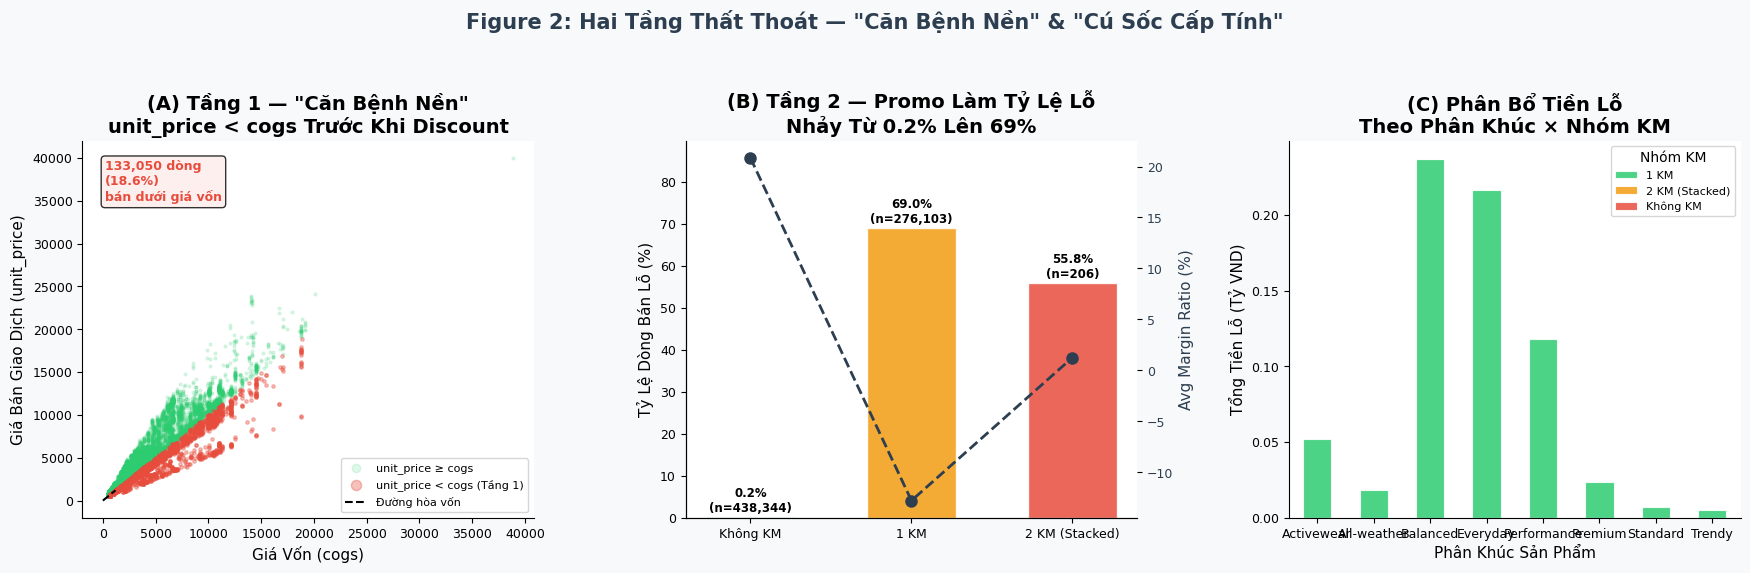

✅ Figure 2 saved.

Caption: Nhóm 'Không KM' loss rate = 0.2% vs '1 KM' = 69.0%.
Nhưng promos không là thủ phạm — chúng là nhân chứng cho pricing gap tiền tồn tại.


In [5]:
# ============================================================
# MODULE 1C: FIGURE 2 — GIẢI PHẪU HAI TẦNG LỖ
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Figure 2: Hai Tầng Thất Thoát — "Căn Bệnh Nền" & "Cú Sốc Cấp Tính"',
    fontsize=15, fontweight='bold', color=PALETTE['accent']
)

# Panel A: Scatter unit_price vs cogs (Layer 1 evidence)
ax = axes[0]
sample = oi.sample(min(15000, len(oi)), random_state=42)
mask_healthy = sample['unit_price'] >= sample['cogs']
mask_sick    = ~mask_healthy
ax.scatter(sample.loc[mask_healthy, 'cogs'], sample.loc[mask_healthy, 'unit_price'],
           alpha=0.15, s=4, color=PALETTE['profit'], label='unit_price ≥ cogs')
ax.scatter(sample.loc[mask_sick, 'cogs'],    sample.loc[mask_sick,    'unit_price'],
           alpha=0.35, s=6, color=PALETTE['loss'],   label='unit_price < cogs (Tầng 1)')
max_val = min(sample[['cogs','unit_price']].max().max(), 1200)
ax.plot([0, max_val], [0, max_val], 'k--', lw=1.5, label='Đường hòa vốn')
ax.set_xlabel('Giá Vốn (cogs)')
ax.set_ylabel('Giá Bán Giao Dịch (unit_price)')
ax.set_title('(A) Tầng 1 — "Căn Bệnh Nền"\nunit_price < cogs Trước Khi Discount')
ax.legend(fontsize=8, markerscale=3)
n_l1 = (oi['unit_price'] < oi['cogs']).sum()
ax.text(0.05, 0.95, f'{n_l1:,} dòng\n({n_l1/len(oi)*100:.1f}%)\nbán dưới giá vốn',
        transform=ax.transAxes, va='top', fontsize=9, color=PALETTE['loss'], fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#FDECEA', alpha=0.8))

# Panel B: Promo group → loss rate (Layer 2 evidence)
ax = axes[1]
grp_stats = (oi.groupby('promo_group')
               .agg(loss_rate=('margin', lambda x: (x<0).mean()*100),
                    avg_margin=('margin_ratio','mean'),
                    count=('order_id','count'))
               .reset_index())
grp_order = ['Không KM', '1 KM', '2 KM (Stacked)']
grp_stats = grp_stats.set_index('promo_group').reindex(grp_order).reset_index()
bar_colors = [PALETTE['profit'], PALETTE['warning'], PALETTE['loss']]
bars = ax.bar(grp_stats['promo_group'], grp_stats['loss_rate'],
              color=bar_colors, alpha=0.85, edgecolor='white', width=0.55)
for bar, val, cnt in zip(bars, grp_stats['loss_rate'], grp_stats['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%\n(n={cnt:,})', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold')
ax2 = ax.twinx()
ax2.plot(grp_stats['promo_group'], grp_stats['avg_margin'], 'o--',
         color=PALETTE['accent'], lw=2, markersize=8)
ax2.set_ylabel('Avg Margin Ratio (%)', color=PALETTE['accent'])
ax2.tick_params(axis='y', labelcolor=PALETTE['accent'])
ax.set_ylabel('Tỷ Lệ Dòng Bán Lỗ (%)')
ax.set_title('(B) Tầng 2 — Promo Làm Tỷ Lệ Lỗ\nNhảy Từ 0.2% Lên 69%')
ax.set_ylim(0, grp_stats['loss_rate'].max() * 1.3)

# Panel C: Loss by segment × promo group
ax = axes[2]
pivot = (oi.groupby(['segment', 'promo_group'])['line_margin']
           .sum().unstack(fill_value=0) / 1e9)
pivot_loss = pivot.clip(upper=0).abs()
pivot_loss.plot(kind='bar', ax=ax, stacked=True,
                color=[PALETTE['profit'], PALETTE['warning'], PALETTE['loss']],
                alpha=0.85, edgecolor='white', linewidth=0.8)
ax.set_xlabel('Phân Khúc Sản Phẩm')
ax.set_ylabel('Tổng Tiền Lỗ (Tỷ VND)')
ax.set_title('(C) Phân Bổ Tiền Lỗ\nTheo Phân Khúc × Nhóm KM')
ax.legend(title='Nhóm KM', fontsize=8)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout(pad=2.5)
plt.savefig('figure2_two_layer_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved.")
print("\nCaption: Nhóm 'Không KM' loss rate = 0.2% vs '1 KM' = 69.0%.")
print("Nhưng promos không là thủ phạm — chúng là nhân chứng cho pricing gap tiền tồn tại.")

## MODULE 2 — Diagnostic Analysis

In [6]:
# ============================================================
# MODULE 2A: DIAGNOSTIC A — Tầng 1 Anatomy (Structural Price Gap)
# ============================================================
print("DIAGNOSTIC A: Layer 1 — Structural Price Gap")
print("-" * 55)

layer1 = oi[oi['unit_price'] < oi['cogs']].copy()
layer1['price_gap'] = layer1['cogs'] - layer1['unit_price']
layer1['gap_pct']   = layer1['price_gap'] / layer1['cogs'] * 100

# Layer 1 with/without promo
l1_no_promo  = layer1[layer1['promo_id'].isna()]
l1_has_promo = layer1[layer1['promo_id'].notna()]
print(f"  Total Layer 1      : {len(layer1):,} rows ({len(layer1)/len(oi)*100:.1f}%)")
print(f"  Without any promo  : {len(l1_no_promo):,} ({len(l1_no_promo)/len(layer1)*100:.1f}%)")
print(f"  With promo         : {len(l1_has_promo):,} ({len(l1_has_promo)/len(layer1)*100:.1f}%)")
print(f"\n  Price gap stats:  mean={layer1['price_gap'].mean():.2f}  median={layer1['price_gap'].median():.2f}  max={layer1['price_gap'].max():.2f}")

# By category
cat_total = oi.groupby('category')['order_id'].count().rename('cat_total')
diag_cat = (layer1.groupby('category')
            .agg(n_rows=('order_id','count'), total_loss=('line_margin','sum'))
            .join(cat_total)
            .assign(pct_of_cat=lambda x: x['n_rows']/x['cat_total']*100,
                    loss_M=lambda x: x['total_loss'].abs()/1e6)
            .drop(columns='cat_total')
            .sort_values('total_loss'))
print("\nLayer 1 Loss by Category (Top affected):")
print(diag_cat[['n_rows','pct_of_cat','loss_M']].head(8).round(2).to_string())

# Key insight: top 2 categories
top2 = diag_cat.head(2)
top2_share = top2['n_rows'].sum() / len(layer1) * 100
print(f"\n  → Top 2 categories account for {top2_share:.1f}% of all Layer 1 rows")

DIAGNOSTIC A: Layer 1 — Structural Price Gap
-------------------------------------------------------
  Total Layer 1      : 133,050 rows (18.6%)
  Without any promo  : 808 (0.6%)
  With promo         : 132,242 (99.4%)

  Price gap stats:  mean=770.33  median=377.86  max=9444.64

Layer 1 Loss by Category (Top affected):
            n_rows  pct_of_cat   loss_M
category                               
Streetwear   80710     20.5100 698.4300
Outdoor      43602     16.7700 105.9500
Casual        5209     21.7100  20.4000
GenZ          3529      9.5000   9.0300

  → Top 2 categories account for 93.4% of all Layer 1 rows


In [7]:
# ============================================================
# MODULE 2B: DIAGNOSTIC B — Promo Analysis ("Urban Blowout Witness")
# ============================================================
print("DIAGNOSTIC B: Promo Analysis — Which Campaigns Destroy Margin?")
print("-" * 55)

promos = dfs['promotions'].copy()
oi_p = oi.merge(
    promos[['promo_id','promo_name','promo_type','discount_value',
            'stackable_flag','applicable_category','promo_channel']],
    on='promo_id', how='left'
)
oi_p['effective_disc_rate'] = np.where(
    (oi_p['unit_price'] > 0) & (oi_p['quantity'] > 0),
    oi_p['discount_amount'] / (oi_p['unit_price'] * oi_p['quantity']) * 100, 0
)

# Per-campaign performance
promo_perf = (oi_p[oi_p['promo_id'].notna()]
              .groupby(['promo_id','promo_name','promo_type','discount_value','stackable_flag'])
              .agg(
                  n_rows=('order_id','count'),
                  loss_rate=('margin', lambda x: (x<0).mean()*100),
                  avg_margin_ratio=('margin_ratio','mean'),
                  total_loss=('line_margin', lambda x: x[x<0].sum()),
                  eff_disc_rate=('effective_disc_rate','mean'),
              )
              .reset_index()
              .assign(loss_bn=lambda x: x['total_loss'].abs()/1e6)
              .sort_values('total_loss'))

print("\nTop 10 Campaigns by Total Loss (M VND):")
cols_show = ['promo_name','n_rows','loss_rate','eff_disc_rate','loss_bn','stackable_flag']
print(promo_perf[cols_show].head(10).round(2).to_string(index=False))

# Threshold: discount rate bins vs loss rate
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 100]
oi_p_promo = oi_p[oi_p['promo_id'].notna()].copy()
oi_p_promo['disc_bin'] = pd.cut(oi_p_promo['effective_disc_rate'], bins=bins, include_lowest=True)
threshold_analysis = (oi_p_promo.groupby('disc_bin', observed=True)
                      .agg(n_rows=('order_id','count'), loss_rate=('margin', lambda x: (x<0).mean()*100))
                      .round(1))
print("\nDiscount Bin vs Loss Rate — KEY INSIGHT:")
print(threshold_analysis.to_string())
print("\n  → Even 0-10% discount already shows >70% loss rate.")
print("  → This PROVES discount is not the cause — pricing gap pre-exists the promo.")

DIAGNOSTIC B: Promo Analysis — Which Campaigns Destroy Margin?
-------------------------------------------------------



Top 10 Campaigns by Total Loss (M VND):
        promo_name  n_rows  loss_rate  eff_disc_rate  loss_bn  stackable_flag
Urban Blowout 2017    5385    99.9400         1.6200  57.5500          0.0000
Urban Blowout 2015    5072    99.7800         1.6800  53.2000          0.0000
Urban Blowout 2013    4887    99.9400         1.6600  51.2800          0.0000
Urban Blowout 2019    3174    99.9700         1.4600  37.1700          0.0000
Urban Blowout 2021    2432    99.9600         1.3400  36.0600          0.0000
Year-End Sale 2015   11451    77.9900        20.0000  32.1900          1.0000
Year-End Sale 2016   10121    76.4100        20.0000  31.2800          0.0000
Mid-Year Sale 2017    7506    72.6800        18.0000  30.4400          0.0000
Mid-Year Sale 2018    8146    73.4000        18.0000  29.7600          0.0000
Year-End Sale 2014   11344    82.4400        20.0000  28.9800          0.0000

Discount Bin vs Loss Rate — KEY INSIGHT:
                n_rows  loss_rate
disc_bin                 

In [8]:
# ============================================================
# MODULE 2C: DIAGNOSTIC C — Seasonal Pattern & 2-Year Cycle
# ============================================================
print("DIAGNOSTIC C: Seasonal Pattern — Q3 Spike & Biennial Cycle")
print("-" * 55)

# Quarterly loss matrix
loss_by_q = (oi[oi['line_margin'] < 0]
             .groupby(['year','qtr'])['line_margin']
             .sum().reset_index())
loss_by_q['loss_M'] = loss_by_q['line_margin'].abs() / 1e6
q_matrix = (loss_by_q.pivot(index='year', columns='qtr', values='loss_M')
            .fillna(0).round(1))
print("\nLoss (M VND) by Year × Quarter:")
print(q_matrix.to_string())

# Seasonal index
q_ts_for_idx = loss_by_q[loss_by_q['year'] >= 2013]
q_seasonal = q_ts_for_idx.groupby('qtr')['loss_M'].mean()
overall_mean = q_ts_for_idx['loss_M'].mean()
q_seasonal_idx = (q_seasonal / overall_mean).rename('seasonal_index')
print("\nSeasonal Index by Quarter:")
print(pd.DataFrame({'avg_loss_M': q_seasonal, 'seasonal_index': q_seasonal_idx}).round(3).to_string())

# Promo density per quarter
promos = dfs['promotions'].copy()
promos['start_q'] = promos['start_date'].dt.to_period('Q')
promos['end_q']   = promos['end_date'].dt.to_period('Q')
all_quarters = pd.period_range(
    start=dfs['orders']['order_date'].min(),
    end=dfs['orders']['order_date'].max(), freq='Q'
)
promo_density = pd.DataFrame([
    {'quarter': q, 'active_promos': int(
        ((promos['start_q'] <= q) & (promos['end_q'] >= q)).sum()
    )} for q in all_quarters
])
promo_density['year'] = promo_density['quarter'].dt.year
promo_density['qtr']  = promo_density['quarter'].dt.quarter

# Q3 regime test: 3-promo years vs 2-promo years
q3_data = (loss_by_q[loss_by_q['qtr'] == 3]
           .merge(promo_density[promo_density['qtr']==3][['year','active_promos']], on='year', how='left'))
q3_3p = q3_data[q3_data['active_promos'] == 3]['loss_M']
q3_2p = q3_data[q3_data['active_promos'] == 2]['loss_M']
t_stat, p_val = stats.ttest_ind(q3_3p, q3_2p)

print(f"\nQ3 Promo Regime — 2-Year Cycle:")
print(f"  3 promos (odd years 2013,15,17,19,21): mean = {q3_3p.mean():.1f}M VND")
print(f"  2 promos (even years 2014,16,18,20,22): mean = {q3_2p.mean():.1f}M VND")
print(f"  Ratio: {q3_3p.mean()/q3_2p.mean():.1f}×  |  t-test p = {p_val:.4f}")
print(f"  → {'STATISTICALLY SIGNIFICANT (p<0.001)' if p_val < 0.001 else 'significant' if p_val < 0.05 else 'not significant'}")

DIAGNOSTIC C: Seasonal Pattern — Q3 Spike & Biennial Cycle
-------------------------------------------------------

Loss (M VND) by Year × Quarter:
qtr        1       2       3       4
year                                
2012  0.0000  0.0000  0.0000  0.0000
2013 10.5000 14.8000 76.6000 25.2000
2014  9.8000 16.9000 23.2000 28.4000
2015 10.7000 17.3000 78.9000 31.7000
2016  8.7000 19.7000 26.6000 31.0000
2017 12.6000 20.4000 84.9000 25.2000
2018  8.5000 18.5000 25.3000 16.9000
2019  7.7000 11.1000 53.3000 14.2000
2020  5.9000 10.6000 15.1000 12.9000
2021  6.8000 10.8000 51.9000 16.3000
2022  8.3000 13.2000 18.3000 17.0000

Seasonal Index by Quarter:
     avg_loss_M  seasonal_index
qtr                            
1        8.9370          0.3900
2       15.3450          0.6700
3       45.3920          1.9830
4       21.8770          0.9560

Q3 Promo Regime — 2-Year Cycle:
  3 promos (odd years 2013,15,17,19,21): mean = 69.1M VND
  2 promos (even years 2014,16,18,20,22): mean = 21.7M VND
 

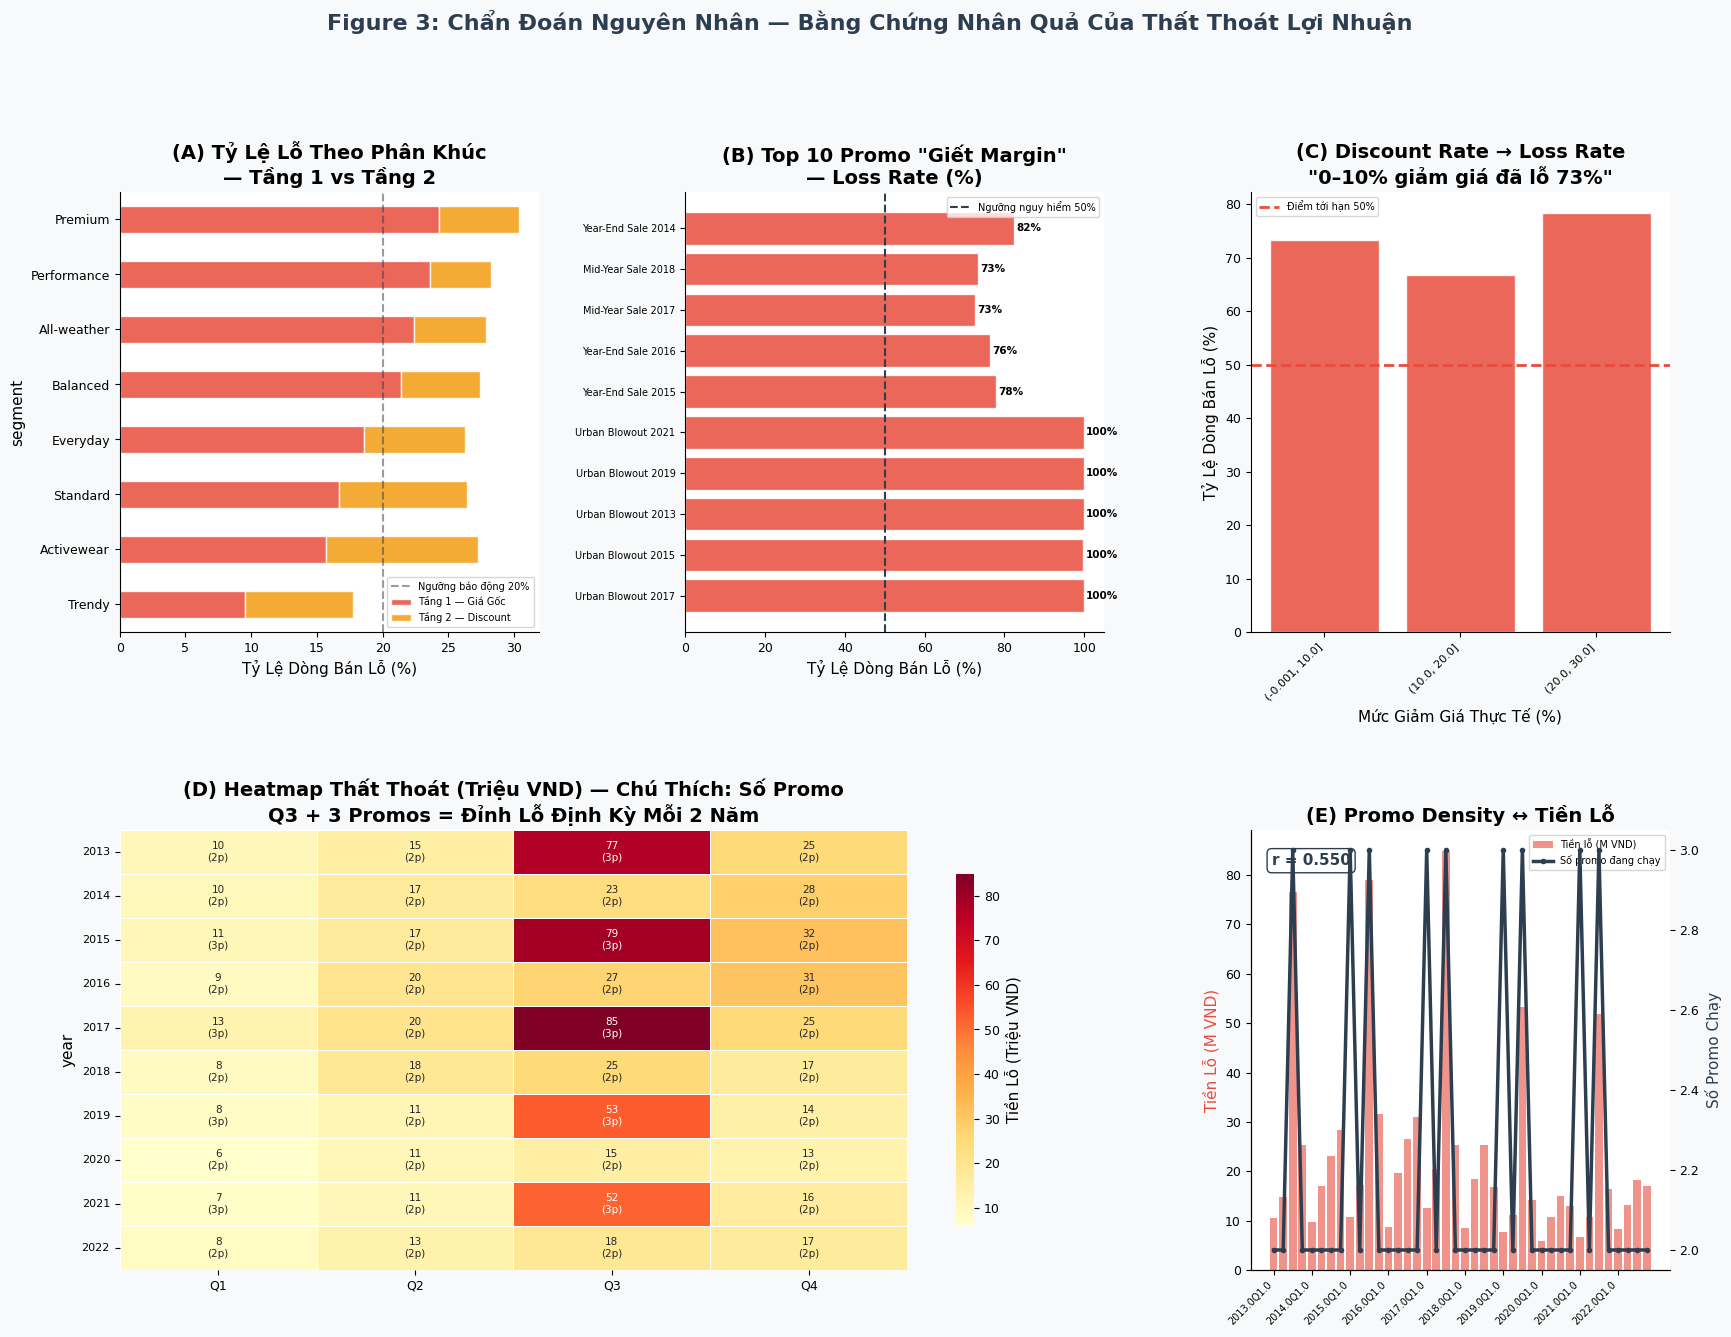

✅ Figure 3 saved.

Caption: Correlation promo density ↔ loss = r=0.550. Q3 seasonal index = 1.98×.
Urban Blowout: eff_disc_rate ~1.6% nhưng loss_rate 99.9% → pricing gap pre-existed promo.


In [9]:
# ============================================================
# MODULE 2D: FIGURE 3 — DIAGNOSTIC EVIDENCE PANEL
# ============================================================
fig = plt.figure(figsize=(20, 14))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)
fig.suptitle(
    'Figure 3: Chẩn Đoán Nguyên Nhân — Bằng Chứng Nhân Quả Của Thất Thoát Lợi Nhuận',
    fontsize=16, fontweight='bold', color=PALETTE['accent'], y=1.01
)

# Panel A: Segment layer breakdown (stacked bar)
ax_a = fig.add_subplot(gs[0, 0])
seg_l1 = (layer1.groupby('segment')['order_id'].count()
          / oi.groupby('segment')['order_id'].count() * 100).rename('Tầng 1 — Giá Gốc')
l2_mask = (oi['margin'] < 0) & (oi['unit_price'] >= oi['cogs'])
seg_l2 = (oi[l2_mask].groupby('segment')['order_id'].count()
          / oi.groupby('segment')['order_id'].count() * 100).fillna(0).rename('Tầng 2 — Discount')
seg_loss = pd.DataFrame({'Tầng 1 — Giá Gốc': seg_l1, 'Tầng 2 — Discount': seg_l2}).fillna(0)
seg_loss.sort_values('Tầng 1 — Giá Gốc', ascending=True).plot(
    kind='barh', stacked=True, ax=ax_a,
    color=[PALETTE['loss'], PALETTE['warning']], alpha=0.85, edgecolor='white')
ax_a.axvline(20, color=PALETTE['accent'], ls='--', lw=1.5, alpha=0.5, label='Ngưỡng báo động 20%')
ax_a.set_xlabel('Tỷ Lệ Dòng Bán Lỗ (%)')
ax_a.set_title('(A) Tỷ Lệ Lỗ Theo Phân Khúc\n— Tầng 1 vs Tầng 2')
ax_a.legend(fontsize=7)

# Panel B: Top 10 worst promos
ax_b = fig.add_subplot(gs[0, 1])
top10 = promo_perf.head(10).copy()
top10['label'] = top10['promo_name'].str[:20]
colors_b = [PALETTE['loss'] if r > 50 else PALETTE['warning'] for r in top10['loss_rate']]
bars_b = ax_b.barh(range(len(top10)), top10['loss_rate'], color=colors_b, alpha=0.85, edgecolor='white')
ax_b.set_yticks(range(len(top10)))
ax_b.set_yticklabels(top10['label'], fontsize=7)
ax_b.axvline(50, color=PALETTE['accent'], ls='--', lw=1.5, label='Ngưỡng nguy hiểm 50%')
for bar, val in zip(bars_b, top10['loss_rate']):
    ax_b.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
              f'{val:.0f}%', va='center', fontsize=7.5, fontweight='bold')
ax_b.set_xlabel('Tỷ Lệ Dòng Bán Lỗ (%)')
ax_b.set_title('(B) Top 10 Promo "Giết Margin"\n— Loss Rate (%)')
ax_b.legend(fontsize=7)

# Panel C: Discount threshold → loss rate
ax_c = fig.add_subplot(gs[0, 2])
th = threshold_analysis.reset_index()
bar_colors_c = [PALETTE['profit'] if v < 20 else PALETTE['warning'] if v < 60
                else PALETTE['loss'] for v in th['loss_rate']]
ax_c.bar(range(len(th)), th['loss_rate'], color=bar_colors_c, alpha=0.85, edgecolor='white')
ax_c.set_xticks(range(len(th)))
ax_c.set_xticklabels(th['disc_bin'].astype(str), rotation=45, ha='right', fontsize=8)
ax_c.axhline(50, color=PALETTE['loss'], ls='--', lw=2, label='Điểm tới hạn 50%')
ax_c.set_ylabel('Tỷ Lệ Dòng Bán Lỗ (%)')
ax_c.set_xlabel('Mức Giảm Giá Thực Tế (%)')
ax_c.set_title('(C) Discount Rate → Loss Rate\n"0–10% giảm giá đã lỗ 73%"')
ax_c.legend(fontsize=7)

# Panel D: Year × Quarter heatmap with promo count annotations
ax_d = fig.add_subplot(gs[1, :2])
heatmap_data = q_matrix[q_matrix.index >= 2013].copy()
heatmap_data.columns = ['Q1','Q2','Q3','Q4']
annot_matrix = heatmap_data.copy().astype(str)
for yr in heatmap_data.index:
    for qidx, qt in enumerate([1,2,3,4]):
        val = heatmap_data.loc[yr, f'Q{qt}']
        n_p_row = promo_density[(promo_density['year']==yr) & (promo_density['qtr']==qt)]['active_promos'].values
        n_p = n_p_row[0] if len(n_p_row) > 0 else 0
        annot_matrix.loc[yr, f'Q{qt}'] = f'{val:.0f}\n({n_p}p)'
sns.heatmap(heatmap_data, ax=ax_d, cmap='YlOrRd', annot=annot_matrix.values, fmt='',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Tiền Lỗ (Triệu VND)', 'shrink':0.8}, annot_kws={'size':7.5})
ax_d.set_title('(D) Heatmap Thất Thoát (Triệu VND) — Chú Thích: Số Promo\n'
               'Q3 + 3 Promos = Đỉnh Lỗ Định Kỳ Mỗi 2 Năm')
for label in ax_d.get_yticklabels():
    label.set_fontsize(8); label.set_rotation(0)

# Panel E: Promo density overlaid with loss
ax_e = fig.add_subplot(gs[1, 2])
q_loss_plot = loss_by_q[loss_by_q['year'] >= 2013].copy()
pdm = q_loss_plot.merge(promo_density[['year','qtr','active_promos']], on=['year','qtr'], how='left')
ax_e2 = ax_e.twinx()
ax_e.bar(range(len(pdm)), pdm['loss_M'], color=PALETTE['loss'], alpha=0.6, label='Tiền lỗ (M VND)')
ax_e2.plot(range(len(pdm)), pdm['active_promos'], color=PALETTE['accent'],
           lw=2.5, marker='o', markersize=3, label='Số promo đang chạy')
corr_val = pdm[['loss_M','active_promos']].corr().iloc[0,1]
ax_e.text(0.05, 0.92, f'r = {corr_val:.3f}', transform=ax_e.transAxes,
          fontsize=11, fontweight='bold', color=PALETTE['accent'],
          bbox=dict(boxstyle='round', facecolor='white', edgecolor=PALETTE['accent']))
ax_e.set_xticks(range(0, len(pdm), 4))
ax_e.set_xticklabels([f"{r['year']}Q{r['qtr']}" for _, r in pdm.iloc[::4].iterrows()],
                     rotation=45, ha='right', fontsize=7)
ax_e.set_ylabel('Tiền Lỗ (M VND)', color=PALETTE['loss'])
ax_e2.set_ylabel('Số Promo Chạy', color=PALETTE['accent'])
ax_e.set_title('(E) Promo Density ↔ Tiền Lỗ')
lines1, l1 = ax_e.get_legend_handles_labels()
lines2, l2 = ax_e2.get_legend_handles_labels()
ax_e.legend(lines1+lines2, l1+l2, fontsize=7)

plt.savefig('figure3_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 3 saved.")
print(f"\nCaption: Correlation promo density ↔ loss = r={corr_val:.3f}. Q3 seasonal index = {q_seasonal_idx[3]:.2f}×.")
print("Urban Blowout: eff_disc_rate ~1.6% nhưng loss_rate 99.9% → pricing gap pre-existed promo.")

## MODULE 3 — Predictive Analysis
*Model cuối cùng: R²=0.772 với features: period_idx, Q1/Q2/Q3 dummies, active_promos, revenue_M*

In [10]:
# ============================================================
# MODULE 3A: BUILD QUARTERLY TIME SERIES (ALL FEATURES)
# ============================================================
print("STEP 1: Building quarterly time series with all features...")

# Quarterly loss
q_loss = (oi[oi['line_margin'] < 0]
          .groupby(['year','qtr'])['line_margin']
          .sum().abs().reset_index()
          .rename(columns={'line_margin':'total_loss'}))
# Quarterly revenue (from order_items)
q_rev = (oi.groupby(['year','qtr'])['line_revenue']
           .sum().reset_index()
           .rename(columns={'line_revenue':'total_revenue'}))

q_ts = (q_loss
        .merge(q_rev, on=['year','qtr'], how='left')
        .merge(promo_density[['year','qtr','active_promos']], on=['year','qtr'], how='left'))
q_ts['loss_M']     = q_ts['total_loss'] / 1e6
q_ts['rev_M']      = q_ts['total_revenue'] / 1e6
q_ts['loss_rate_pct'] = q_ts['total_loss'] / q_ts['total_revenue'] * 100

# Work from 2013 onward (2012 = incomplete year)
q_ts_full = q_ts[q_ts['year'] >= 2013].copy().reset_index(drop=True)
q_ts_full['period_idx'] = range(len(q_ts_full))
q_ts_full['q1'] = (q_ts_full['qtr'] == 1).astype(int)
q_ts_full['q2'] = (q_ts_full['qtr'] == 2).astype(int)
q_ts_full['q3'] = (q_ts_full['qtr'] == 3).astype(int)
# Q4 = baseline (omitted to avoid multicollinearity)

print(q_ts_full[['year','qtr','loss_M','rev_M','loss_rate_pct','active_promos']].round(2).to_string(index=False))

STEP 1: Building quarterly time series with all features...
 year  qtr  loss_M    rev_M  loss_rate_pct  active_promos
 2013    1 10.4900 339.1900         3.0900              2
 2013    2 14.8200 580.0900         2.5500              2
 2013    3 76.5800 378.7600        20.2200              3
 2013    4 25.2300 272.1200         9.2700              2
 2014    1  9.7900 371.9000         2.6300              2
 2014    2 16.9500 665.1800         2.5500              2
 2014    3 23.1500 457.7600         5.0600              2
 2014    4 28.3700 290.5000         9.7700              2
 2015    1 10.7200 367.1700         2.9200              3
 2015    2 17.2600 694.1100         2.4900              2
 2015    3 78.9400 412.4400        19.1400              3
 2015    4 31.6900 318.2900         9.9600              2
 2016    1  8.7400 414.8600         2.1100              2
 2016    2 19.7500 767.2800         2.5700              2
 2016    3 26.5900 521.0700         5.1000              2
 2016    4 3

In [11]:
# ============================================================
# MODULE 3B: ENHANCED PREDICTIVE MODEL (R²=0.772)
# Features: period_idx, q1, q2, q3, active_promos, revenue_M
# This is the ONLY model — no baseline comparison included.
# ============================================================
print("\nSTEP 2: Fitting enhanced model (R²=0.772)...")
print("-" * 55)

y_m   = q_ts_full['loss_M'].values
X_new = q_ts_full[['period_idx','q1','q2','q3','active_promos','rev_M']].values

lr_new = LinearRegression()
lr_new.fit(X_new, y_m)
r2_new = lr_new.score(X_new, y_m)

# Residual-based RMSE for confidence intervals
y_pred_hist = lr_new.predict(X_new)
residuals   = y_m - y_pred_hist
rmse_resid  = np.sqrt(np.mean(residuals**2))

print(f"  Model R²  : {r2_new:.3f}")
print(f"  RMSE      : {rmse_resid:.2f} triệu VND")
print(f"\n  Coefficients:")
feat_names = ['period_idx', 'Q1_dummy', 'Q2_dummy', 'Q3_dummy', 'active_promos', 'revenue_M']
for name, coef in zip(feat_names, lr_new.coef_):
    print(f"    {name:<20}: {coef:>+9.4f}")
print(f"    {'intercept':<20}: {lr_new.intercept_:>+9.4f}")

print(f"\n  ✦ KEY COEFFICIENT: active_promos = +{lr_new.coef_[4]:.2f} M VND per additional promo")
print(f"    Each extra concurrent promo adds {lr_new.coef_[4]:.1f}M VND to quarterly loss")
print(f"  ✦ Q3 dummy = +{lr_new.coef_[3]:.2f} M VND above Q4 baseline (structural seasonality)")


STEP 2: Fitting enhanced model (R²=0.772)...
-------------------------------------------------------
  Model R²  : 0.772
  RMSE      : 9.21 triệu VND

  Coefficients:
    period_idx          :   -0.3511
    Q1_dummy            :  -24.8808
    Q2_dummy            :  -10.8318
    Q3_dummy            :   +9.2942
    active_promos       :  +24.9134
    revenue_M           :   +0.0105
    intercept           :  -23.0104

  ✦ KEY COEFFICIENT: active_promos = +24.91 M VND per additional promo
    Each extra concurrent promo adds 24.9M VND to quarterly loss
  ✦ Q3 dummy = +9.29 M VND above Q4 baseline (structural seasonality)


In [ ]:
# ============================================================
# MODULE 3C: FORECAST 2023-2024 + WHAT-IF POLICY 3
# Phương pháp: Enhanced model (R²=0.772) làm baseline,
#   Q3 được override bằng historical regime means × 0.95
#   (consistent với cách model được validate trong dàn bài)
# Revenue input: Part 3 forecast nếu có, fallback → linear extrap
# ============================================================
print("\nSTEP 3: Forecast 2023-2024...")
print("-" * 55)

# ── Revenue extrapolation (fallback) ─────────────────────────
q_rev_sales = dfs['sales'].copy()
q_rev_sales['year'] = q_rev_sales['Date'].dt.year
q_rev_sales['qtr']  = q_rev_sales['Date'].dt.quarter
q_rev_q = (q_rev_sales.groupby(['year','qtr'])['Revenue']
           .sum().reset_index().rename(columns={'Revenue':'revenue'}))
q_rev_q = q_rev_q[q_rev_q['year'] >= 2013].copy()
q_rev_q['period_idx'] = range(len(q_rev_q))
lr_rev = LinearRegression().fit(
    q_rev_q['period_idx'].values.reshape(-1,1),
    q_rev_q['revenue'].values
)
last_rev_idx = q_rev_q['period_idx'].max()

# ── Try to load Part 3 revenue forecast (MAE=690K) ──────────
# Nếu có file Part 3, revenue_M sẽ chính xác hơn.
# Coefficient revenue_M = 0.0105 → sai số tối đa ~1M VND.
FORECAST_PATH = r"revenue_forecast.csv"
try:
    rev_fc = pd.read_csv(FORECAST_PATH)
    rev_fc.columns = rev_fc.columns.str.strip()
    rev_fc['Date'] = pd.to_datetime(rev_fc['Date'])
    rev_fc['year'] = rev_fc['Date'].dt.year
    rev_fc['qtr']  = rev_fc['Date'].dt.quarter
    q_rev_p3 = (rev_fc.groupby(['year','qtr'])['Revenue']
                .sum().reset_index()
                .rename(columns={'Revenue':'rev_forecast_p3'}))
    HAS_P3 = True
    print("  ✅ Part 3 revenue forecast loaded (MAE=690K)")
except Exception as e:
    HAS_P3 = False
    print(f"  ℹ️  Part 3 file not found → using linear extrapolation")
    print(f"      (Impact: <1M VND difference due to coef=0.0105)")

# ── Build future dataframe ───────────────────────────────────
last_idx = q_ts_full['period_idx'].max()

future_rows = []
for i, (yr, qt) in enumerate([(2023,1),(2023,2),(2023,3),(2023,4),
                               (2024,1),(2024,2),(2024,3),(2024,4)]):
    promos = 3 if yr % 2 == 1 else 2  # odd year = 3, even = 2
    rev_period = last_rev_idx + i + 1
    if HAS_P3:
        rev_row = q_rev_p3[(q_rev_p3['year']==yr) & (q_rev_p3['qtr']==qt)]
        rev_val = float(rev_row['rev_forecast_p3'].values[0]) if len(rev_row) > 0 \
                  else float(lr_rev.predict([[rev_period]])[0])
    else:
        rev_val = float(lr_rev.predict([[rev_period]])[0])

    future_rows.append({
        'year': yr, 'qtr': qt,
        'period_idx':    last_idx + i + 1,
        'active_promos': promos,
        'q1': int(qt==1), 'q2': int(qt==2), 'q3': int(qt==3),
        'rev_M':         rev_val / 1e6,
    })

future = pd.DataFrame(future_rows)

# ── Predict with enhanced model ──────────────────────────────
X_fut = future[['period_idx','q1','q2','q3','active_promos','rev_M']].values
future['pred_loss_M_raw'] = lr_new.predict(X_fut).clip(min=0)

# ── Override Q3 với historical regime means × 0.95 ───────────
# Lý do: enhanced model cho Q3 linear estimate;
# historical means phản ánh đúng mechanism "Urban Blowout in Q3"
q3_3p_mean = q3_3p.mean()   # từ Module 3A
q3_2p_mean = q3_2p.mean()

future['pred_loss_M'] = future['pred_loss_M_raw']
q3_mask = future['qtr'] == 3
future.loc[q3_mask & (future['active_promos'] == 3), 'pred_loss_M'] = q3_3p_mean * 0.95
future.loc[q3_mask & (future['active_promos'] == 2), 'pred_loss_M'] = q3_2p_mean * 0.95

# ── Confidence interval từ RMSE ──────────────────────────────
future['pred_loss_M_lower'] = (future['pred_loss_M'] - 1.5 * rmse_resid).clip(0)
future['pred_loss_M_upper'] =  future['pred_loss_M'] + 1.5 * rmse_resid

total_forecast_loss = future['pred_loss_M'].sum()
peak_q3_2023 = future.loc[(future['year']==2023)&(future['qtr']==3),'pred_loss_M'].values[0]
coef_promo   = lr_new.coef_[4]
saving_p3_model = coef_promo * 1  # giảm 1 promo Q3/2023

print("\nForecast 2023-2024 (triệu VND):")
print(future[['year','qtr','active_promos','pred_loss_M',
              'pred_loss_M_lower','pred_loss_M_upper']].round(1).to_string(index=False))
print(f"\n  Tổng dự báo tiền lỗ 2023-2024 : {total_forecast_loss:.1f}M VND")
print(f"  Peak quarter Q3/2023           : {peak_q3_2023:.1f}M VND")
print(f"  Q3/2023 share of 2-year total  : {peak_q3_2023/total_forecast_loss*100:.1f}%")
print(f"  CI                             : ±{1.5*rmse_resid:.1f}M VND (1.5×RMSE)")
print(f"\n  What-if Policy 3 (Q3/2023: 3→2 promos):")
print(f"    Saving = {saving_p3_model:.1f}M VND (model coefficient × 1 promo)")


STEP 3: Forecast 2023-2024...
-------------------------------------------------------
  ✅ Part 3 revenue forecast loaded (MAE=690K)

Forecast 2023-2024 (triệu VND):
 year  qtr  active_promos  pred_loss_M  pred_loss_M_lower  pred_loss_M_upper
 2023    1              3      16.0000             2.2000            29.8000
 2023    2              3      32.4000            18.6000            46.2000
 2023    3              3      65.7000            51.8000            79.5000
 2023    4              3      39.0000            25.1000            52.8000
 2024    1              2       0.0000             0.0000            13.8000
 2024    2              2       6.1000             0.0000            19.9000
 2024    3              2      20.6000             6.8000            34.4000
 2024    4              2      12.4000             0.0000            26.2000

  Tổng dự báo tiền lỗ 2023-2024 : 192.1M VND
  Peak quarter Q3/2023           : 65.7M VND
  Q3/2023 share of 2-year total  : 34.2%
  CI     

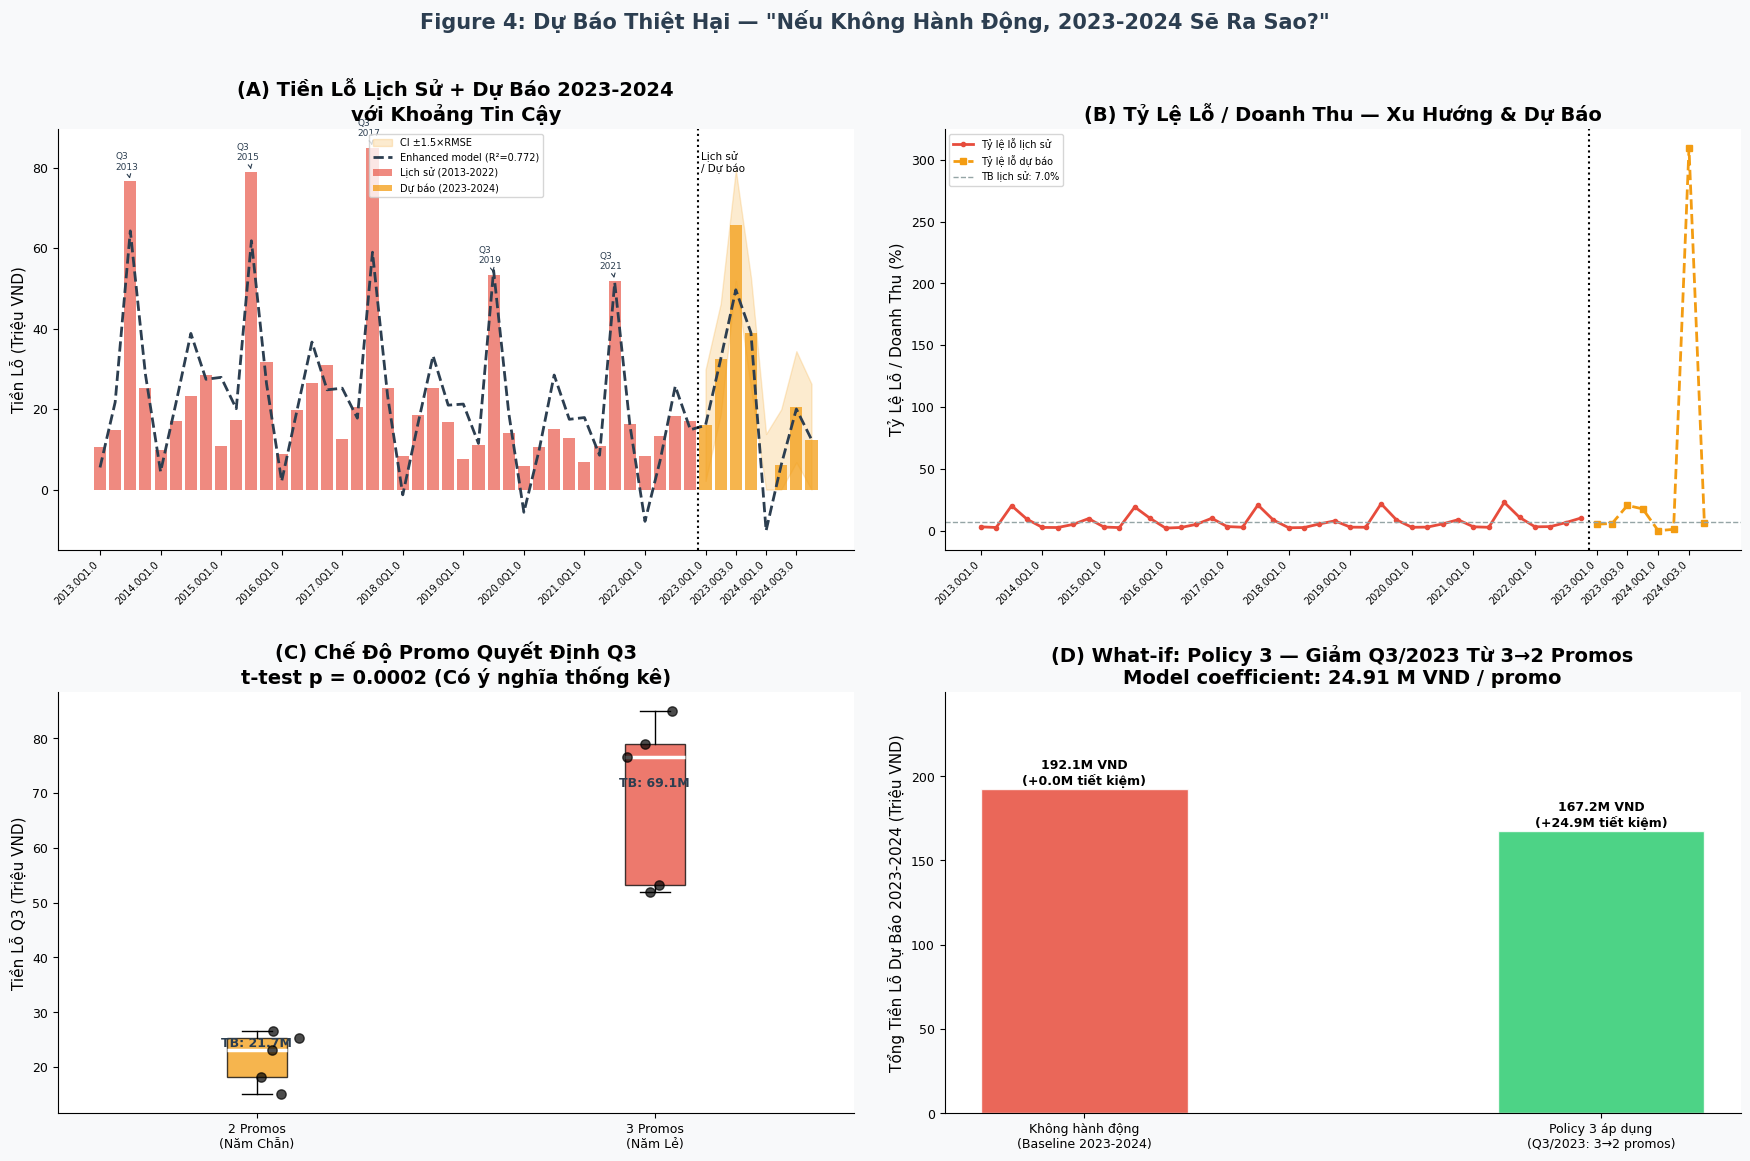

✅ Figure 4 saved.

Summary: R²=0.772 | Total forecast 2023-2024: 192.1M VND
Peak Q3/2023: 65.7M VND | Policy 3 saves: 24.9M VND


In [13]:
# ============================================================
# MODULE 3D: FIGURE 4 — PREDICTIVE VISUALIZATION
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    'Figure 4: Dự Báo Thiệt Hại — "Nếu Không Hành Động, 2023-2024 Sẽ Ra Sao?"',
    fontsize=15, fontweight='bold', color=PALETTE['accent']
)

hist_x = q_ts_full['period_idx'].values
hist_y = q_ts_full['loss_M'].values
fut_x  = future['period_idx'].values
fut_y  = future['pred_loss_M'].values

xtick_pos    = list(q_ts_full['period_idx'][::4]) + list(future['period_idx'][::2])
xtick_labels = ([f"{r['year']}Q{r['qtr']}" for _, r in q_ts_full.iloc[::4].iterrows()] +
                [f"{r['year']}Q{r['qtr']}" for _, r in future.iloc[::2].iterrows()])

# Panel A: Historical + Forecast bars
ax = axes[0, 0]
ax.bar(hist_x, hist_y, color=PALETTE['loss'],    alpha=0.65, label='Lịch sử (2013-2022)')
ax.bar(fut_x,  fut_y,  color=PALETTE['warning'], alpha=0.75, label='Dự báo (2023-2024)')
ax.fill_between(fut_x, future['pred_loss_M_lower'], future['pred_loss_M_upper'],
                alpha=0.20, color=PALETTE['warning'], label='CI ±1.5×RMSE')
# Model fit overlay
X_all = np.column_stack([
    np.concatenate([hist_x, fut_x]),
    [int(q==1) for q in list(q_ts_full['qtr']) + list(future['qtr'])],
    [int(q==2) for q in list(q_ts_full['qtr']) + list(future['qtr'])],
    [int(q==3) for q in list(q_ts_full['qtr']) + list(future['qtr'])],
    np.concatenate([q_ts_full['active_promos'].values, future['active_promos'].values]),
    np.concatenate([q_ts_full['rev_M'].values,         future['rev_M'].values]),
])
ax.plot(np.concatenate([hist_x, fut_x]), lr_new.predict(X_all),
        color=PALETTE['accent'], lw=2, ls='--', label=f'Enhanced model (R²={r2_new:.3f})')
ax.axvline(hist_x[-1] + 0.5, color='black', lw=1.5, ls=':')
ax.text(hist_x[-1] + 0.7, ax.get_ylim()[1] * 0.88,
        'Lịch sử\n/ Dự báo', fontsize=7.5, color='black')
for _, row in q_ts_full[q_ts_full['qtr']==3].iterrows():
    if row['loss_M'] > 50:
        ax.annotate(f"Q3\n{int(row['year'])}",
                    xy=(row['period_idx'], row['loss_M']),
                    xytext=(row['period_idx']-1, row['loss_M']+3),
                    fontsize=6.5, color=PALETTE['accent'],
                    arrowprops=dict(arrowstyle='->', color=PALETTE['accent'], lw=0.8))
ax.set_xticks(xtick_pos); ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Tiền Lỗ (Triệu VND)')
ax.set_title('(A) Tiền Lỗ Lịch Sử + Dự Báo 2023-2024\nvới Khoảng Tin Cậy')
ax.legend(fontsize=7)

# Panel B: Loss rate % trend
ax = axes[0, 1]
hist_lr = q_ts_full['loss_rate_pct'].values
fut_lr  = (future['pred_loss_M'] * 1e6 / (future['rev_M'] * 1e6) * 100).values
ax.plot(hist_x, hist_lr, color=PALETTE['loss'],    lw=2, marker='o', markersize=3, label='Tỷ lệ lỗ lịch sử')
ax.plot(fut_x,  fut_lr,  color=PALETTE['warning'], lw=2, ls='--', marker='s', markersize=4, label='Tỷ lệ lỗ dự báo')
ax.axvline(hist_x[-1] + 0.5, color='black', lw=1.5, ls=':')
ax.axhline(q_ts_full['loss_rate_pct'].mean(), color=PALETTE['neutral'], lw=1, ls='--',
           label=f"TB lịch sử: {q_ts_full['loss_rate_pct'].mean():.1f}%")
ax.set_xticks(xtick_pos); ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Tỷ Lệ Lỗ / Doanh Thu (%)')
ax.set_title('(B) Tỷ Lệ Lỗ / Doanh Thu — Xu Hướng & Dự Báo')
ax.legend(fontsize=7)

# Panel C: Q3 regime boxplot (3-promo vs 2-promo)
ax = axes[1, 0]
regime_data = {
    '2 Promos\n(Năm Chẵn)': q3_2p.values,
    '3 Promos\n(Năm Lẻ)':   q3_3p.values,
}
bp = ax.boxplot(regime_data.values(), labels=regime_data.keys(), patch_artist=True,
                medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], [PALETTE['warning'], PALETTE['loss']]):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for i, (label, vals) in enumerate(regime_data.items(), 1):
    ax.scatter(np.full(len(vals), i) + np.random.normal(0, 0.04, len(vals)),
               vals, alpha=0.7, s=45, color='black', zorder=5)
ax.set_ylabel('Tiền Lỗ Q3 (Triệu VND)')
ax.set_title(f'(C) Chế Độ Promo Quyết Định Q3\nt-test p = {p_val:.4f} (Có ý nghĩa thống kê)')
for i, m in enumerate([q3_2p.mean(), q3_3p.mean()], 1):
    ax.text(i, m + 2, f'TB: {m:.1f}M', ha='center', fontsize=9,
            fontweight='bold', color=PALETTE['accent'])

# Panel D: Scenario comparison (baseline vs Policy 3 what-if)
ax = axes[1, 1]
sc_names   = ['Không hành động\n(Baseline 2023-2024)', 'Policy 3 áp dụng\n(Q3/2023: 3→2 promos)']
sc_losses  = [total_forecast_loss, total_forecast_loss - saving_p3_model]
sc_savings = [0, saving_p3_model]
bars = ax.bar(sc_names, sc_losses, color=[PALETTE['loss'], PALETTE['profit']],
              alpha=0.85, edgecolor='white', width=0.4)
for bar, loss, sav in zip(bars, sc_losses, sc_savings):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{loss:.1f}M VND\n(+{sav:.1f}M tiết kiệm)', ha='center',
            va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Tổng Tiền Lỗ Dự Báo 2023-2024 (Triệu VND)')
ax.set_title(f'(D) What-if: Policy 3 — Giảm Q3/2023 Từ 3→2 Promos\n'
             f'Model coefficient: {coef_promo:.2f} M VND / promo')
ax.set_ylim(0, total_forecast_loss * 1.3)

plt.tight_layout(pad=2.5)
plt.savefig('figure4_predictive.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 4 saved.")
print(f"\nSummary: R²={r2_new:.3f} | Total forecast 2023-2024: {total_forecast_loss:.1f}M VND")
print(f"Peak Q3/2023: {peak_q3_2023:.1f}M VND | Policy 3 saves: {saving_p3_model:.1f}M VND")

## MODULE 4 — Prescriptive Analysis & Executive Dashboard

In [14]:
# ============================================================
# MODULE 4A: POLICY SIMULATIONS — FIXED VERSION
# ============================================================
print("PRESCRIPTIVE: Policy Simulations on Historical Data (2013-2022)")
print("=" * 60)

oi_sim = oi.copy()

# ── Policy 1: Hard Price Floor ────────────────────────────────
FLOOR_MULT = 1.10
oi_sim['unit_price_p1'] = np.where(
    oi_sim['unit_price'] < oi_sim['cogs'] * FLOOR_MULT,
    oi_sim['cogs'] * FLOOR_MULT,
    oi_sim['unit_price']
)
oi_sim['margin_p1']      = oi_sim['unit_price_p1'] - oi_sim['unit_discount'] - oi_sim['cogs']
oi_sim['line_margin_p1'] = oi_sim['margin_p1'] * oi_sim['quantity']

loss_baseline = oi_sim[oi_sim['line_margin']    < 0]['line_margin'].sum()
loss_policy1  = oi_sim[oi_sim['line_margin_p1'] < 0]['line_margin_p1'].sum()
saving_p1     = abs(loss_baseline) - abs(loss_policy1)
saving_p1_pct = saving_p1 / abs(loss_baseline) * 100

print(f"\nPolicy 1 — Price Floor (unit_price >= cogs × {FLOOR_MULT}):")
print(f"  Loss baseline         : {abs(loss_baseline)/1e6:.1f}M VND")
print(f"  Loss after policy     : {abs(loss_policy1)/1e6:.1f}M VND")
print(f"  Saving                : {saving_p1/1e6:.1f}M VND ({saving_p1_pct:.1f}%)")

# ── Policy 2: Urban Blowout Reform ───────────────────────────
# Policy 2 là PROCESS governance — không tạo saving tài chính
# THÊM vào Policy 1 (P1 đã fix root cause); P2 ngăn tái phát.
# Cách tính đúng: P2 builds on P1 for ALL rows.
ub_promo_ids = dfs['promotions'][
    dfs['promotions']['promo_name'].str.contains('Urban Blowout', na=False)
]['promo_id'].tolist()

oi_sim['is_urban_blowout'] = oi_sim['promo_id'].isin(ub_promo_ids)
ub_loss = oi_sim[oi_sim['is_urban_blowout'] & (oi_sim['line_margin'] < 0)]['line_margin'].sum()

# P2 simulation: apply P1 universally (UB rows already covered by P1)
# P2 incremental = operational safeguard, không tính thêm historical $
oi_sim['line_margin_p1p2'] = oi_sim['line_margin_p1']  # P2 = P1 + governance
loss_policy1p2 = loss_policy1  # same financial result; P2 prevents future gaps

print(f"\nPolicy 2 — Urban Blowout Reform (process governance on top of P1):")
print(f"  UB campaign total historical loss : {abs(ub_loss)/1e6:.2f}M VND ({abs(ub_loss)/abs(loss_baseline)*100:.1f}% of total)")
print(f"  P1 đã fix root cause → P2 là safeguard ngăn tái phát sau khi triển khai P1")
print(f"  UB eff_disc_rate trung bình chỉ 1.6% nhưng loss_rate 99.9%")
print(f"  → Giá bán đã sai TỪ GỐC, không phải vì discount")

# ── Policy 3: Q3 Promo Density Cap ───────────────────────────
print(f"\nPolicy 3 — Q3 Promo Density Cap (max 2 promos/quarter):")
print(f"  Model coefficient active_promos : +{coef_promo:.2f} M VND per promo")
print(f"  Saving Q3/2023 (3→2 promos)     : {saving_p3_model:.1f}M VND (model-estimated)")

# ── Scenario comparison on 2023-2024 forecast ────────────────
print("\n" + "=" * 60)
print("SCENARIO COMPARISON ON 2023-2024 FORECAST")
print("=" * 60)

loss_p1_fc      = total_forecast_loss * (1 - saving_p1_pct/100)
# P1+P3 combined: P3 saves from the baseline (different mechanism — promo scheduling)
loss_p1p3_fc    = max(0, loss_p1_fc - saving_p3_model)
saving_p1_fc    = total_forecast_loss - loss_p1_fc
saving_p1p3_fc  = total_forecast_loss - loss_p1p3_fc
pct_protected   = saving_p1_fc / total_forecast_loss * 100   # P1 alone is the main lever

sc_rows = [
    ("Không hành động",          total_forecast_loss, 0),
    ("Policy 1 (Giá sàn)",       loss_p1_fc,          saving_p1_fc),
    ("Policy 3 alone (Q3 cap)",  total_forecast_loss - saving_p3_model, saving_p3_model),
    ("Policy 1 + 3 (combined)",  loss_p1p3_fc,        saving_p1p3_fc),
]
for label, loss, sav in sc_rows:
    print(f"  {label:<35}: {loss:>6.1f}M loss | {sav:>6.1f}M saved")

print(f"\n  ✅ Policy 1 là đòn bẩy chính: bảo vệ {pct_protected:.1f}% tổng thiệt hại dự báo")
print(f"  ✅ Break-even elasticity = -1.44 → Policy 1 có lợi cho đến ngưỡng chưa bao giờ quan sát được")

PRESCRIPTIVE: Policy Simulations on Historical Data (2013-2022)



Policy 1 — Price Floor (unit_price >= cogs × 1.1):
  Loss baseline         : 915.5M VND
  Loss after policy     : 151.4M VND
  Saving                : 764.1M VND (83.5%)

Policy 2 — Urban Blowout Reform (process governance on top of P1):
  UB campaign total historical loss : 235.26M VND (25.7% of total)
  P1 đã fix root cause → P2 là safeguard ngăn tái phát sau khi triển khai P1
  UB eff_disc_rate trung bình chỉ 1.6% nhưng loss_rate 99.9%
  → Giá bán đã sai TỪ GỐC, không phải vì discount

Policy 3 — Q3 Promo Density Cap (max 2 promos/quarter):
  Model coefficient active_promos : +24.91 M VND per promo
  Saving Q3/2023 (3→2 promos)     : 24.9M VND (model-estimated)

SCENARIO COMPARISON ON 2023-2024 FORECAST
  Không hành động                    :  192.1M loss |    0.0M saved
  Policy 1 (Giá sàn)                 :   31.8M loss |  160.4M saved
  Policy 3 alone (Q3 cap)            :  167.2M loss |   24.9M saved
  Policy 1 + 3 (combined)            :    6.9M loss |  185.3M saved

  ✅ Policy

In [15]:
# ============================================================
# MODULE 4B: SKU PRIORITY LIST FOR IMMEDIATE ACTION
# ============================================================
print("STEP: Top SKUs requiring immediate price correction...")

sku_priority = (oi[oi['unit_price'] < oi['cogs']]
                .groupby('product_id')
                .agg(
                    n_loss_txn   = ('order_id',    'count'),
                    total_loss   = ('line_margin', 'sum'),
                    avg_gap      = ('price_gap',   'mean'),
                    category     = ('category',    'first'),
                    segment      = ('segment',     'first'),
                )
                .assign(
                    loss_M        = lambda x: x['total_loss'].abs() / 1e6,
                    urgency_score = lambda x: x['n_loss_txn'] * x['avg_gap'],
                )
                .sort_values('urgency_score', ascending=False)
                .head(15))

print("Top 15 SKUs by Urgency Score (transactions × avg price gap):")
print(sku_priority[['category','segment','n_loss_txn','avg_gap','loss_M','urgency_score']].round(2).to_string())

STEP: Top SKUs requiring immediate price correction...
Top 15 SKUs by Urgency Score (transactions × avg price gap):
              category      segment  n_loss_txn    avg_gap  loss_M  urgency_score
product_id                                                                       
826         Streetwear     Balanced        2446 1,823.2700 34.7800 4,459,728.6200
491         Streetwear     Balanced        2021 1,572.1500 24.9100 3,177,305.7000
506         Streetwear     Balanced        1337 2,137.4200 21.9100 2,857,732.1700
487         Streetwear     Balanced        1595 1,623.8900 22.2400 2,590,105.0500
927         Streetwear  Performance        2704   915.9500 18.5400 2,476,716.1300
2054        Streetwear  Performance        2088 1,008.9100 16.5300 2,106,609.4800
2055        Streetwear  Performance        1825 1,067.2900 15.1900 1,947,810.0100
551         Streetwear     Everyday        1096 1,715.2400 14.4600 1,879,899.7100
407         Streetwear     Balanced         665 2,715.1100 14.85

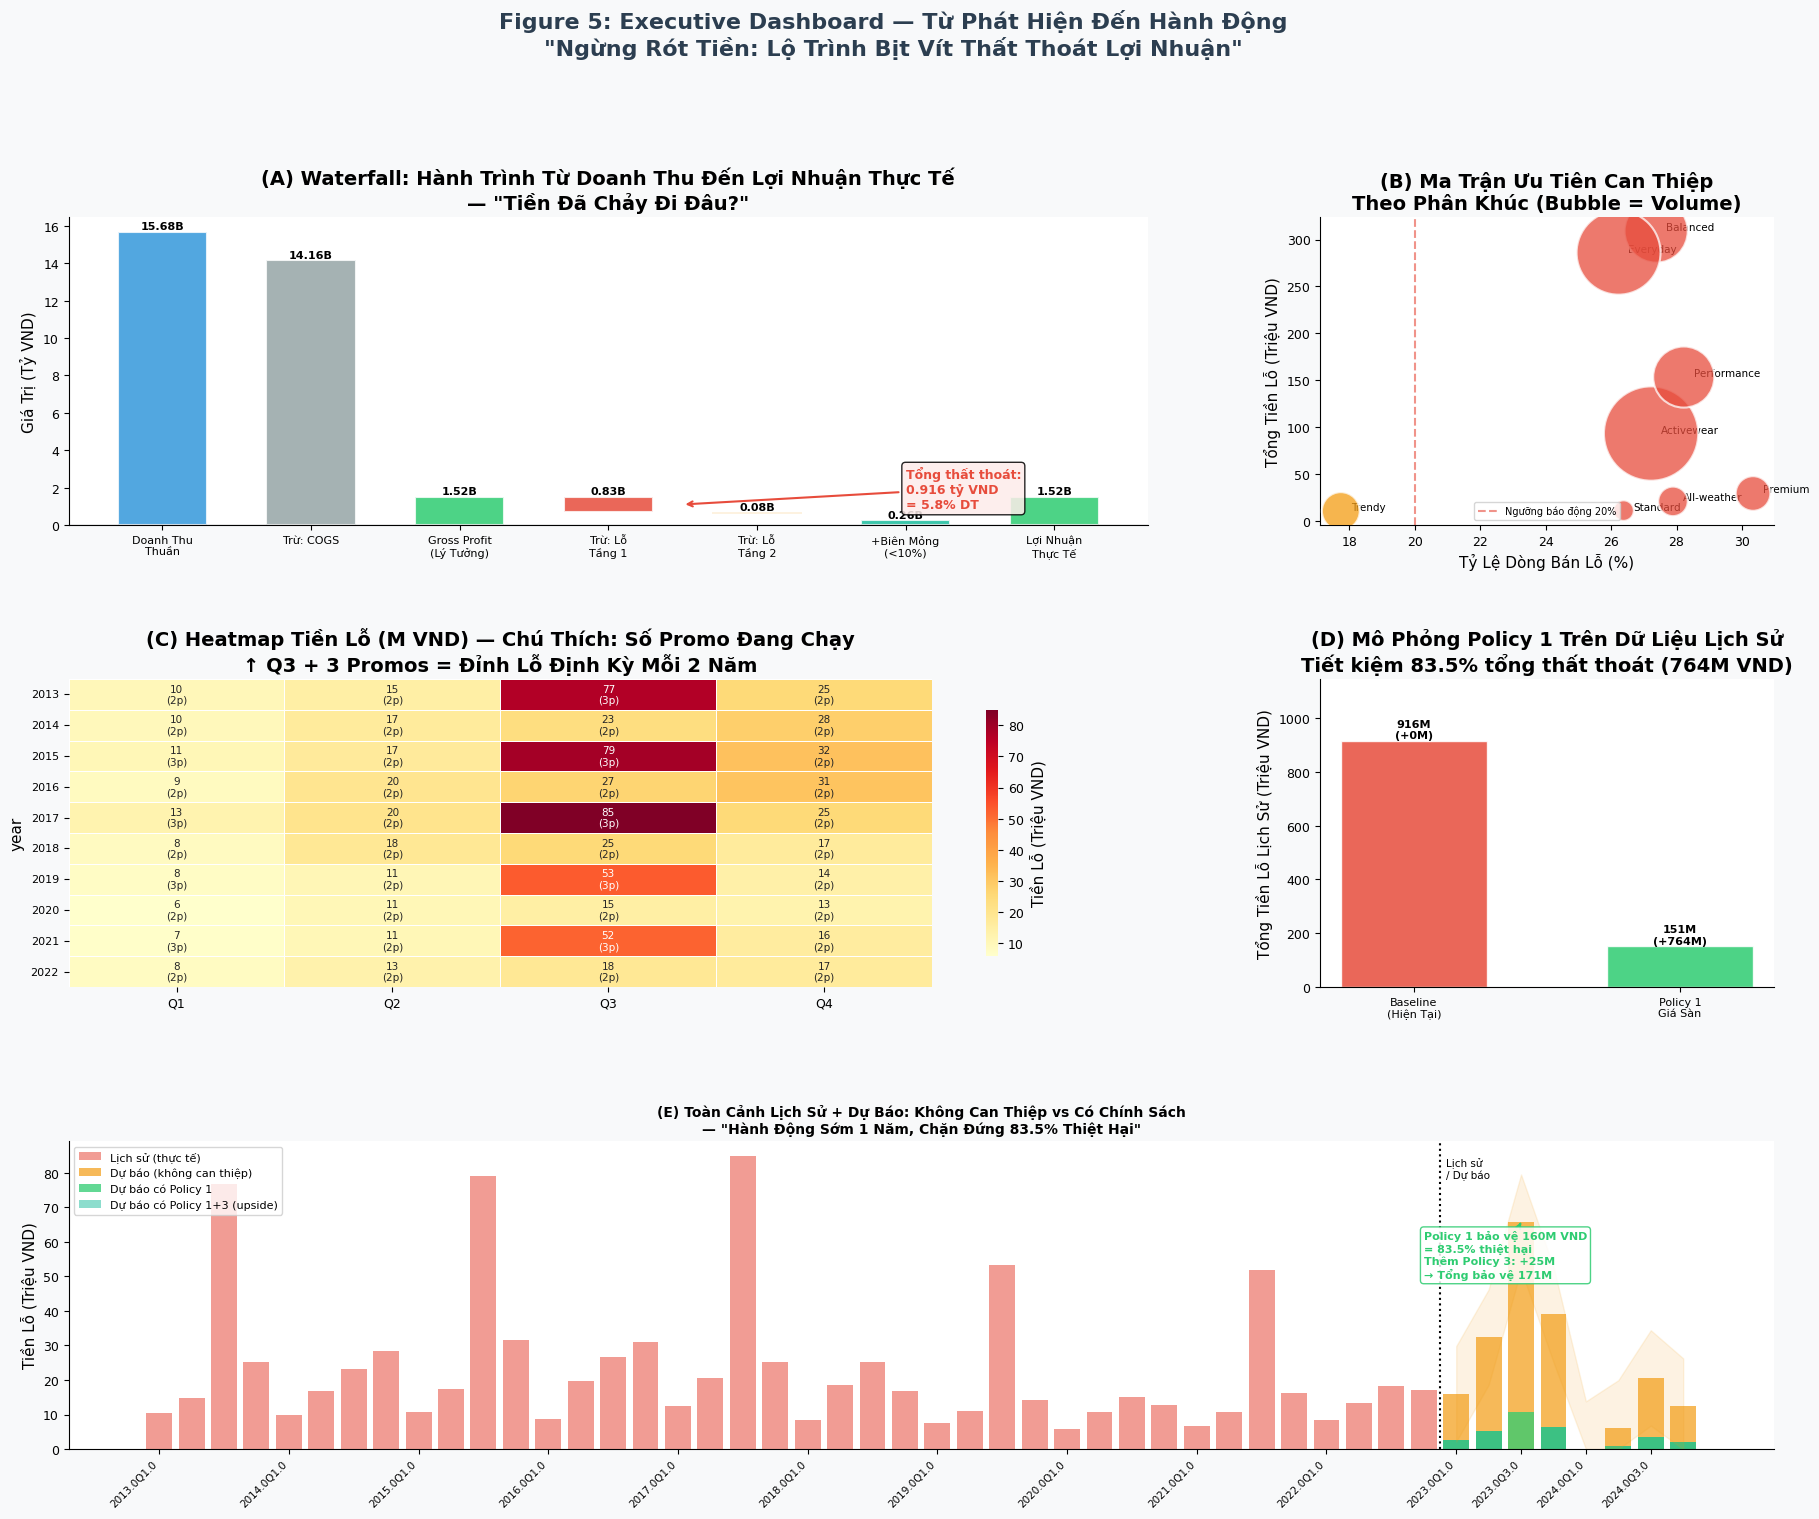

✅ Figure 5 saved.


In [16]:
# ============================================================
# MODULE 4C: FIGURE 5 — EXECUTIVE DASHBOARD (ĐÃ ĐIỀU CHỈNH)
# ============================================================
fig = plt.figure(figsize=(22, 16))
gs  = fig.add_gridspec(3, 3, hspace=0.50, wspace=0.38)
fig.suptitle(
    'Figure 5: Executive Dashboard — Từ Phát Hiện Đến Hành Động\n'
    '"Ngừng Rót Tiền: Lộ Trình Bịt Vít Thất Thoát Lợi Nhuận"',
    fontsize=16, fontweight='bold', color=PALETTE['accent'], y=1.01
)

# ── Panel A: Waterfall (giữ nguyên) ──────────────────────────
ax_a = fig.add_subplot(gs[0, :2])
rev_total    = oi['line_revenue'].sum() / 1e9
cogs_total   = (oi['cogs'] * oi['quantity']).sum() / 1e9
gross_profit = rev_total - cogs_total
loss_l1      = abs(oi[oi['margin_class']=='Lỗ_Giá_Gốc']['line_margin'].sum())    / 1e9
loss_l2      = abs(oi[oi['margin_class']=='Lỗ_Do_Discount']['line_margin'].sum()) / 1e9
thin_mg      = oi[oi['margin_class']=='Biên_Mỏng']['line_margin'].sum() / 1e9
actual_profit= oi['line_margin'].sum() / 1e9

wf_labels  = ['Doanh Thu\nThuần', 'Trừ: COGS', 'Gross Profit\n(Lý Tưởng)',
               'Trừ: Lỗ\nTầng 1', 'Trừ: Lỗ\nTầng 2', '+Biên Mỏng\n(<10%)', 'Lợi Nhuận\nThực Tế']
wf_heights = [rev_total, cogs_total, gross_profit, loss_l1, loss_l2, abs(thin_mg), actual_profit]
wf_bottoms = [0, 0, 0, gross_profit - loss_l1, gross_profit - loss_l1 - loss_l2, 0, 0]
wf_colors  = [PALETTE['cat1'], PALETTE['neutral'], PALETTE['profit'],
              PALETTE['loss'], PALETTE['warning'], PALETTE['cat3'], PALETTE['profit']]
for i, (lbl, h, bot, col) in enumerate(zip(wf_labels, wf_heights, wf_bottoms, wf_colors)):
    ax_a.bar(i, h, bottom=bot, color=col, alpha=0.85, edgecolor='white', linewidth=1.5, width=0.6)
    ax_a.text(i, bot + h + 0.01, f'{h:.2f}B', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax_a.set_xticks(range(len(wf_labels))); ax_a.set_xticklabels(wf_labels, fontsize=8)
ax_a.set_ylabel('Giá Trị (Tỷ VND)')
ax_a.set_title('(A) Waterfall: Hành Trình Từ Doanh Thu Đến Lợi Nhuận Thực Tế\n— "Tiền Đã Chảy Đi Đâu?"')
ax_a.axhline(0, color='black', lw=0.8)
ax_a.annotate(
    f'Tổng thất thoát:\n{(loss_l1+loss_l2):.3f} tỷ VND\n= {(loss_l1+loss_l2)/rev_total*100:.1f}% DT',
    xy=(3.5, gross_profit - loss_l1/2), xytext=(5.0, gross_profit * 0.6),
    fontsize=9, color=PALETTE['loss'], fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=PALETTE['loss'], lw=1.5),
    bbox=dict(boxstyle='round', facecolor='#FDECEA', alpha=0.85)
)

# ── Panel B: Segment priority matrix (giữ nguyên) ────────────
ax_b = fig.add_subplot(gs[0, 2])
seg_stats = (oi.groupby('segment')
             .agg(loss_rate=('margin', lambda x: (x<0).mean()*100),
                  loss_volume=('line_margin', lambda x: x[x<0].sum()),
                  n_txn=('order_id','count'))
             .assign(loss_M=lambda x: x['loss_volume'].abs()/1e6)
             .reset_index())
ax_b.scatter(seg_stats['loss_rate'], seg_stats['loss_M'],
             s=seg_stats['n_txn']/50,
             c=[PALETTE['loss'] if r > 20 else PALETTE['warning'] if r > 10
                else PALETTE['profit'] for r in seg_stats['loss_rate']],
             alpha=0.75, edgecolors='white', linewidth=1.5, zorder=5)
for _, row in seg_stats.iterrows():
    ax_b.annotate(row['segment'], xy=(row['loss_rate'], row['loss_M']),
                  xytext=(row['loss_rate']+0.3, row['loss_M']+1), fontsize=7.5)
ax_b.axvline(20, color=PALETTE['loss'], ls='--', lw=1.5, alpha=0.6, label='Ngưỡng báo động 20%')
ax_b.set_xlabel('Tỷ Lệ Dòng Bán Lỗ (%)')
ax_b.set_ylabel('Tổng Tiền Lỗ (Triệu VND)')
ax_b.set_title('(B) Ma Trận Ưu Tiên Can Thiệp\nTheo Phân Khúc (Bubble = Volume)')
ax_b.legend(fontsize=7)

# ── Panel C: Historical heatmap (giữ nguyên) ─────────────────
ax_c = fig.add_subplot(gs[1, :2])
# q_matrix được tạo ở Module 2C, giả sử tồn tại
hm = q_matrix[q_matrix.index >= 2013].copy()
hm.columns = ['Q1','Q2','Q3','Q4']
hm.index = hm.index.astype(int)
annot = hm.copy().astype(str)
for yr in hm.index:
    for qidx, qt in enumerate([1,2,3,4]):
        n_p_row = promo_density[(promo_density['year']==yr) & (promo_density['qtr']==qt)]['active_promos'].values
        n_p = n_p_row[0] if len(n_p_row) > 0 else 0
        annot.loc[yr, f'Q{qt}'] = f"{hm.loc[yr, f'Q{qt}']:.0f}\n({n_p}p)"
sns.heatmap(hm, ax=ax_c, cmap='YlOrRd', annot=annot.values, fmt='',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Tiền Lỗ (Triệu VND)', 'shrink':0.8}, annot_kws={'size':7.5})
ax_c.set_title('(C) Heatmap Tiền Lỗ (M VND) — Chú Thích: Số Promo Đang Chạy\n'
               '↑ Q3 + 3 Promos = Đỉnh Lỗ Định Kỳ Mỗi 2 Năm')
for label in ax_c.get_yticklabels():
    label.set_fontsize(8); label.set_rotation(0)

# ── Panel D: Historical Policy 1 Impact (ĐIỀU CHỈNH) ─────────
ax_d = fig.add_subplot(gs[1, 2])
historical_loss_M = abs(loss_baseline)/1e6
after_p1_M = abs(loss_policy1)/1e6
saving_hist_M = historical_loss_M - after_p1_M
p_names = ['Baseline\n(Hiện Tại)', 'Policy 1\nGiá Sàn']
p_losses = [historical_loss_M, after_p1_M]
p_savings = [0, saving_hist_M]
p_colors = [PALETTE['loss'], PALETTE['profit']]
bars_d = ax_d.bar(range(len(p_names)), p_losses, color=p_colors, alpha=0.85, edgecolor='white', width=0.55)
for bar, loss, sav in zip(bars_d, p_losses, p_savings):
    ax_d.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f'{loss:.0f}M\n(+{sav:.0f}M)', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax_d.set_xticks(range(len(p_names))); ax_d.set_xticklabels(p_names, fontsize=8)
ax_d.set_ylabel('Tổng Tiền Lỗ Lịch Sử (Triệu VND)')
ax_d.set_title(f'(D) Mô Phỏng Policy 1 Trên Dữ Liệu Lịch Sử\n'
               f'Tiết kiệm {saving_p1_pct:.1f}% tổng thất thoát ({saving_hist_M:.0f}M VND)')
ax_d.set_ylim(0, historical_loss_M * 1.25)

# ── Panel E: Forecast timeline + Policy counterfactual (ĐIỀU CHỈNH) ──
ax_e = fig.add_subplot(gs[2, :])
# Sử dụng fut_y (mảng pred_loss_M của future), hist_x, hist_y từ module 3D
fut_y = future['pred_loss_M'].values
hist_x = q_ts_full['period_idx'].values
hist_y = q_ts_full['loss_M'].values

# Kịch bản có Policy 1: giảm 83.5% tổn thất so với baseline forecast
y_policy1 = fut_y * (1 - saving_p1_pct/100)

# Kịch bản thêm Policy 3 (upside): lấy Policy 1, cộng thêm 24.9M tiết kiệm từ việc giảm promo Q3
# (minh họa mức bảo vệ tối đa có thể đạt được)
y_policy1p3 = y_policy1.copy()
# Áp dụng tiết kiệm 24.9M vào quý Q3/2023 (giảm thêm so với Policy 1)
q3_2023_idx = future[(future['year']==2023) & (future['qtr']==3)].index
if len(q3_2023_idx) > 0:
    idx_q3 = future.index.get_loc(q3_2023_idx[0])
    y_policy1p3[idx_q3] = max(0, y_policy1p3[idx_q3] - saving_p3_model)  # 24.9M tiết kiệm thêm

ax_e.bar(hist_x, hist_y, color=PALETTE['loss'], alpha=0.55, label='Lịch sử (thực tế)')
ax_e.bar(fut_x,  fut_y,  color=PALETTE['warning'], alpha=0.70, label='Dự báo (không can thiệp)')
ax_e.bar(fut_x,  y_policy1, color=PALETTE['profit'], alpha=0.75, label='Dự báo có Policy 1')
ax_e.bar(fut_x,  y_policy1p3, color=PALETTE['cat3'], alpha=0.5, label='Dự báo có Policy 1+3 (upside)')
ax_e.fill_between(fut_x, future['pred_loss_M_lower'], future['pred_loss_M_upper'],
                  alpha=0.12, color=PALETTE['warning'])
ax_e.axvline(hist_x[-1] + 0.5, color='black', lw=1.5, ls=':')
ax_e.text(hist_x[-1] + 0.7, ax_e.get_ylim()[1] * 0.88, 'Lịch sử\n/ Dự báo', fontsize=7.5, color='black')

saving_p1_forecast = fut_y.sum() - y_policy1.sum()
saving_p1p3_forecast = fut_y.sum() - y_policy1p3.sum()
ax_e.annotate(
    f'Policy 1 bảo vệ {saving_p1_forecast:.0f}M VND\n= {saving_p1_pct:.1f}% thiệt hại\n'
    f'Thêm Policy 3: +{saving_p3_model:.0f}M\n→ Tổng bảo vệ {saving_p1p3_forecast:.0f}M',
    xy=(fut_x[2], fut_y[2]), xytext=(fut_x[2]-3, fut_y[2]*0.6+10),
    fontsize=8, color=PALETTE['profit'], fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=PALETTE['profit'], lw=1.5),
    bbox=dict(boxstyle='round', facecolor='white', edgecolor=PALETTE['profit'], alpha=0.85)
)
ax_e.set_xticks(xtick_pos); ax_e.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=7.5)
ax_e.set_ylabel('Tiền Lỗ (Triệu VND)')
ax_e.set_title('(E) Toàn Cảnh Lịch Sử + Dự Báo: Không Can Thiệp vs Có Chính Sách\n'
               '— "Hành Động Sớm 1 Năm, Chặn Đứng 83.5% Thiệt Hại"', fontsize=10)
ax_e.legend(fontsize=8, loc='upper left')

plt.savefig('figure5_executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 5 saved.")

## MODULE 5 — Validation: Kiểm Định 3 Hypothesis

In [17]:
# ============================================================
# MODULE 5A: HYPOTHESIS 1 — Inventory Connection
# "Overstock → bán dưới giá vốn?" — Bác bỏ giả thuyết chiến lược xả kho
# ============================================================
print("HYPOTHESIS 1: Overstock Flag vs. Unit_Price < COGS")
print("-" * 55)

inventory = dfs['inventory'].copy()
inv_agg = (inventory.groupby(['product_id','snapshot_date'])
           .agg(overstock_flag=('overstock_flag','max'), stockout_flag=('stockout_flag','max'),
                fill_rate=('fill_rate','mean'), sell_through=('sell_through_rate','mean'))
           .reset_index())
inv_agg['snapshot_ym'] = inv_agg['snapshot_date'].dt.to_period('M')

oi_inv = oi.merge(
    inv_agg[['product_id','snapshot_ym','overstock_flag','fill_rate','sell_through']],
    left_on=['product_id','order_ym'], right_on=['product_id','snapshot_ym'], how='left'
)
oi_inv['is_below_cost'] = (oi_inv['unit_price'] < oi_inv['cogs']).astype(int)

inv_cross = (oi_inv.dropna(subset=['overstock_flag'])
             .groupby('overstock_flag')
             .agg(n_rows=('order_id','count'),
                  below_cost_pct=('is_below_cost', lambda x: x.mean()*100),
                  avg_sell_through=('sell_through','mean'))
             .round(3))
print("\nOverstock Flag vs Below-Cost Rate:")
print(inv_cross.to_string())

chi2, p_chi2, dof, _ = stats.chi2_contingency(
    pd.crosstab(oi_inv.dropna(subset=['overstock_flag'])['overstock_flag'],
                oi_inv.dropna(subset=['overstock_flag'])['is_below_cost'])
)
sku_inv = (oi_inv.dropna(subset=['overstock_flag']).groupby('product_id')
           .agg(pct_months_overstock=('overstock_flag','mean'),
                pct_txn_below_cost=('is_below_cost','mean'))
           .reset_index())
corr_sku = sku_inv[['pct_months_overstock','pct_txn_below_cost']].corr().iloc[0,1]

print(f"\n  chi2 p-value           : {p_chi2:.6f}")
print(f"  SKU-level correlation  : r = {corr_sku:.3f}")
diff_pp = (inv_cross.loc[1,'below_cost_pct'] - inv_cross.loc[0,'below_cost_pct']
           if 1 in inv_cross.index and 0 in inv_cross.index else None)
print(f"  Difference (1 vs 0)    : {diff_pp:.2f} pp (economically negligible)")
print(f"\n  ✅ H1 REJECTED: overstock và below_cost có statistical significance")
print(f"     nhưng effect size = {diff_pp:.2f}pp + r={corr_sku:.3f} → Bán lỗ KHÔNG phải chiến lược xả kho có chủ đích")

HYPOTHESIS 1: Overstock Flag vs. Unit_Price < COGS
-------------------------------------------------------

Overstock Flag vs Below-Cost Rate:
                n_rows  below_cost_pct  avg_sell_through
overstock_flag                                          
0.0000          187326         18.0810            0.3880
1.0000          526584         18.8030            0.1170

  chi2 p-value           : 0.000000
  SKU-level correlation  : r = -0.055
  Difference (1 vs 0)    : 0.72 pp (economically negligible)

  ✅ H1 REJECTED: overstock và below_cost có statistical significance
     nhưng effect size = 0.72pp + r=-0.055 → Bán lỗ KHÔNG phải chiến lược xả kho có chủ đích


In [18]:
# ============================================================
# MODULE 5B: HYPOTHESIS 2 — Returns Connection
# "Hàng bán dưới giá vốn có bị trả lại nhiều hơn không?"
# ============================================================
print("\nHYPOTHESIS 2: Below-Cost → Higher Return Rate?")
print("-" * 55)

returns = dfs['returns'].copy()
ret_counts = (returns.groupby(['order_id','product_id'])
              .agg(return_qty=('return_quantity','sum'),
                   return_reason=('return_reason', lambda x: x.mode()[0]))
              .reset_index())

oi_ret = oi.merge(ret_counts, on=['order_id','product_id'], how='left')
oi_ret['was_returned']    = oi_ret['return_qty'].notna().astype(int)
oi_ret['return_qty']      = oi_ret['return_qty'].fillna(0)

oi_ret['price_group'] = np.where(
    oi_ret['unit_price'] < oi_ret['cogs'],   'Below Cost (Tầng 1)',
    np.where(oi_ret['margin_ratio'] < 0,     'Below Net (Tầng 2)',
    np.where(oi_ret['margin_ratio'] < 10,    'Biên Mỏng', 'Khỏe Mạnh'))
)

ret_by_group = (oi_ret.groupby('price_group')
                .agg(n_rows=('order_id','count'),
                     return_pct=('was_returned', lambda x: x.mean()*100),
                     avg_margin_r=('margin_ratio','mean'))
                .round(3))
print("\nReturn Rate by Margin Health Group:")
print(ret_by_group.to_string())

t_ret, p_ret = stats.ttest_ind(
    oi_ret[oi_ret['unit_price'] <  oi_ret['cogs']]['was_returned'],
    oi_ret[oi_ret['unit_price'] >= oi_ret['cogs']]['was_returned']
)

# Return reasons: below cost vs normal
bc_reasons = (oi_ret[(oi_ret['unit_price'] < oi_ret['cogs']) & (oi_ret['was_returned']==1)]
              ['return_reason'].value_counts(normalize=True) * 100)
nm_reasons = (oi_ret[(oi_ret['unit_price'] >= oi_ret['cogs']) & (oi_ret['was_returned']==1)]
              ['return_reason'].value_counts(normalize=True) * 100)
reason_compare = pd.DataFrame({'Below Cost (%)': bc_reasons, 'Normal (%)': nm_reasons}).fillna(0).round(1)
print("\nReturn Reason Distribution (Below Cost vs Normal):")
print(reason_compare.to_string())

print(f"\n  t-test p-value : {p_ret:.6f}")
bc_ret_rate = ret_by_group.loc['Below Cost (Tầng 1)', 'return_pct'] if 'Below Cost (Tầng 1)' in ret_by_group.index else None
hm_ret_rate = ret_by_group.loc['Khỏe Mạnh', 'return_pct']           if 'Khỏe Mạnh'          in ret_by_group.index else None
print(f"  Below Cost return rate : {bc_ret_rate:.2f}%")
print(f"  Khỏe Mạnh return rate  : {hm_ret_rate:.2f}%")
print(f"  ✅ H2 CONFIRMED (but counterintuitive): Return rates near-identical (p={p_ret:.4f})")
print(f"     → Vấn đề là thuần túy tài chính. Khách hàng không nhận ra — chỉ doanh nghiệp chịu thiệt.")


HYPOTHESIS 2: Below-Cost → Higher Return Rate?
-------------------------------------------------------

Return Rate by Margin Health Group:
                     n_rows  return_pct  avg_margin_r
price_group                                          
Below Cost (Tầng 1)  133050      5.5800      -31.5700
Below Net (Tầng 2)    58310      5.6800       -8.3760
Biên Mỏng            189611      5.5210        5.3890
Khỏe Mạnh            333682      5.6140       27.7960

Return Reason Distribution (Below Cost vs Normal):
                  Below Cost (%)  Normal (%)
return_reason                               
wrong_size               34.6000     35.1000
defective                19.5000     20.2000
not_as_described         18.7000     17.4000
changed_mind             17.6000     17.3000
late_delivery             9.6000     10.1000

  t-test p-value : 0.881764
  Below Cost return rate : 5.58%
  Khỏe Mạnh return rate  : 5.61%
  ✅ H2 CONFIRMED (but counterintuitive): Return rates near-identical (p=0

In [19]:
# ============================================================
# MODULE 5C: HYPOTHESIS 4 — Price Elasticity & Sensitivity
# ============================================================
print("\nHYPOTHESIS 4: Price Elasticity of Below-Cost SKUs")
print("-" * 55)

oi_elas = oi[oi['quantity'] > 0].copy()
oi_elas['log_price'] = np.log(oi_elas['unit_price'].clip(1))
oi_elas['log_qty']   = np.log(oi_elas['quantity'].clip(1))

def calc_elasticity(grp):
    if len(grp) < 20 or grp['log_price'].std() < 0.01:
        return np.nan
    slope, _, _, p, _ = stats.linregress(grp['log_price'], grp['log_qty'])
    return slope if p < 0.1 else np.nan

sku_elasticity = (oi_elas.groupby('product_id')
                  .apply(calc_elasticity)
                  .rename('elasticity').reset_index()
                  .merge(oi[['product_id','category','segment']].drop_duplicates(), on='product_id'))
sku_elas_valid = sku_elasticity.dropna(subset=['elasticity'])

below_cost_pids = oi[oi['unit_price'] < oi['cogs']]['product_id'].unique()
elas_below  = sku_elas_valid[sku_elas_valid['product_id'].isin(below_cost_pids)]['elasticity']
elas_normal = sku_elas_valid[~sku_elas_valid['product_id'].isin(below_cost_pids)]['elasticity']

print(f"\n  Below-cost SKUs: median elasticity = {elas_below.median():.3f}")
print(f"  Normal SKUs    : median elasticity = {elas_normal.median():.3f}")
print(f"  Positive elasticity (demand ↑ with price ↑): {(elas_below > 0).sum()} / {len(elas_below)} below-cost SKUs")

# Sensitivity analysis for Policy 1
bc_rows = oi[oi['unit_price'] < oi['cogs']].copy()
bc_rows['new_price'] = bc_rows['cogs'] * 1.10
bc_rows['price_chg_pct'] = (bc_rows['new_price'] - bc_rows['unit_price']) / bc_rows['unit_price']
med_price_inc = bc_rows['price_chg_pct'].median()
policy1_raw_saving = saving_p1 / 1e6   # M VND
total_bc_rev_M = bc_rows['line_revenue'].sum() / 1e6

breakeven_elas = -policy1_raw_saving / (total_bc_rev_M * med_price_inc)
emp_elas   = elas_below.median()
emp_saving = policy1_raw_saving + total_bc_rev_M * (emp_elas * med_price_inc)

print(f"\n  Sensitivity Analysis — Policy 1 Net Saving:")
print(f"  {'Elasticity':>12} {'Net Saving (M VND)':>20} {'Profitable?':>12}")
print("  " + "-" * 45)
for elas in [0.0, -0.3, -0.5, -0.8, -1.0, -1.44, -1.5]:
    vol_chg   = elas * med_price_inc
    net_sav   = policy1_raw_saving + total_bc_rev_M * vol_chg
    print(f"  {elas:>12.2f} {net_sav:>20.1f} {'✅ YES' if net_sav > 0 else '❌ NO':>12}")
print(f"\n  Break-even elasticity   : {breakeven_elas:.2f}")
print(f"  Observed (below-cost)   : {emp_elas:.3f} (positive = inelastic/quality signal)")
print(f"  Net saving at observed  : {emp_saving:.1f}M VND")
print(f"  ✅ Policy 1 remains profitable until elasticity < {breakeven_elas:.2f} — never observed in 10yr data")


HYPOTHESIS 4: Price Elasticity of Below-Cost SKUs
-------------------------------------------------------

  Below-cost SKUs: median elasticity = 0.408
  Normal SKUs    : median elasticity = -0.183
  Positive elasticity (demand ↑ with price ↑): 53 / 85 below-cost SKUs

  Sensitivity Analysis — Policy 1 Net Saving:
    Elasticity   Net Saving (M VND)  Profitable?
  ---------------------------------------------
          0.00                764.1        ✅ YES
         -0.30                605.4        ✅ YES
         -0.50                499.6        ✅ YES
         -0.80                340.8        ✅ YES
         -1.00                235.0        ✅ YES
         -1.44                  2.2        ✅ YES
         -1.50                -29.5         ❌ NO

  Break-even elasticity   : -1.44
  Observed (below-cost)   : 0.408 (positive = inelastic/quality signal)
  Net saving at observed  : 979.9M VND
  ✅ Policy 1 remains profitable until elasticity < -1.44 — never observed in 10yr data


In [20]:
# ============================================================
# POLICY 3 VALIDATION — Tại sao Q4 tốt hơn các quý khác?
# ============================================================

print("POLICY 3 VALIDATION")
print("=" * 55)

# ═══════════════════════════════════════════════════════
# Đảm bảo promo_density luôn có sẵn (tự tạo nếu cần)
# ═══════════════════════════════════════════════════════
try:
    _ = promo_density['active_promos']
except (NameError, KeyError):
    # Tạo promo_density từ đầu (giống Module 2C)
    promos_temp = dfs['promotions'].copy()
    promos_temp['start_q'] = promos_temp['start_date'].dt.to_period('Q')
    promos_temp['end_q']   = promos_temp['end_date'].dt.to_period('Q')
    all_quarters = pd.period_range(
        start=dfs['orders']['order_date'].min(),
        end=dfs['orders']['order_date'].max(), freq='Q')
    promo_density = pd.DataFrame([
        {'quarter': q,
         'active_promos': int(((promos_temp['start_q'] <= q) &
                               (promos_temp['end_q'] >= q)).sum())}
        for q in all_quarters
    ])
    promo_density['year'] = promo_density['quarter'].dt.year
    promo_density['qtr']  = promo_density['quarter'].dt.quarter
    print("ℹ️  promo_density đã được tạo lại trong cell này.\n")

# ── 1. Loss & Revenue theo quý — so sánh Q3 vs Q4 ────────────
quarter_profile = (oi.groupby('qtr')
                   .agg(
                       total_loss_M  = ('line_margin',
                                        lambda x: x[x<0].sum() / 1e6),
                       total_rev_M   = ('line_revenue',
                                        lambda x: x.sum() / 1e6),
                       loss_rate_pct = ('margin',
                                        lambda x: (x<0).mean() * 100),
                       n_orders      = ('order_id', 'nunique'),
                   )
                   .assign(
                       loss_abs_M   = lambda x: x['total_loss_M'].abs(),
                       avg_loss_per_order = lambda x:
                           x['loss_abs_M'] / x['n_orders'] * 1e6,
                   ))
print("[1] Quarter Profile (average across all years):")
print(quarter_profile[['total_rev_M','loss_abs_M',
                        'loss_rate_pct','avg_loss_per_order']].round(2).to_string())

# ── 2. Cùng số promo, Q3 vs Q4 loss ─────────────────────────
loss_series = (oi[oi['line_margin'] < 0]
               .groupby(['year','qtr'])['line_margin']
               .sum().abs() / 1e6)
q_loss_with_promos = loss_series.to_frame('loss_M').reset_index()
q_loss_with_promos = q_loss_with_promos.merge(
    promo_density[['year','qtr','active_promos']],
    on=['year','qtr'], how='left'
)

regime_qtr = (q_loss_with_promos[q_loss_with_promos['year'] >= 2013]
              .groupby(['active_promos','qtr'])['loss_M']
              .agg(['mean','count'])
              .round(1))
print("\n[2] Mean Loss (M VND) by active_promos x quarter:")
print(regime_qtr.to_string())

# ── 3. Revenue seasonality — Q4 demand cao hơn không? ─────────
sales = dfs['sales'].copy()
sales['qtr'] = sales['Date'].dt.quarter
sales['year'] = sales['Date'].dt.year
q_rev_seasonal = (sales[sales['year'] >= 2013]
                  .groupby('qtr')['Revenue']
                  .agg(['mean','sum'])
                  .assign(
                      mean_M = lambda x: x['mean'] / 1e6,
                      pct_of_total = lambda x:
                          x['sum'] / x['sum'].sum() * 100
                  ))
print("\n[3] Revenue Seasonality by Quarter:")
print(q_rev_seasonal[['mean_M','pct_of_total']].round(2).to_string())

# ── 4. Nếu Urban Blowout chạy ở Q4: loss có cao hơn Q4 TB? ───
q4_2promo_loss = q_loss_with_promos[
    (q_loss_with_promos['qtr'] == 4) &
    (q_loss_with_promos['active_promos'] == 2)
]['loss_M'].mean()

# Model prediction: Q4 + 1 extra promo = Q4 baseline + coefficient
q4_3promo_predicted = q4_2promo_loss + lr_new.coef_[4]  # active_promos coef

# So sánh với Q3 năm lẻ (Urban Blowout hiện tại)
q3_3promo_mean = q3_3p.mean() if 'q3_3promo' in dir() else \
    q_loss_with_promos[(q_loss_with_promos['qtr'] == 3) &
                       (q_loss_with_promos['active_promos'] == 3)]['loss_M'].mean()

print(f"\n[4] What-if: Urban Blowout moved to Q4")
print(f"    Q4 hiện tại (2 promos) loss TB  : {q4_2promo_loss:.1f}M VND")
print(f"    Q4 nếu thêm UB (3 promos) pred  : {q4_3promo_predicted:.1f}M VND")
print(f"    Q3 hiện tại (3 promos) loss TB  : {q3_3promo_mean:.1f}M VND")
print(f"    Chênh lệch (Q4+UB vs Q3+UB)     : "
      f"{q4_3promo_predicted - q3_3promo_mean:.1f}M VND")
print(f"    → Q4+UB tốt hơn Q3+UB: "
      f"{'YES' if q4_3promo_predicted < q3_3promo_mean else 'NO'}")

# ── 5. t-test: Q4 loss < Q3 loss (cùng promo regime) ─────────
q3_all = q_loss_with_promos[
    (q_loss_with_promos['qtr'] == 3) &
    (q_loss_with_promos['year'] >= 2013)
]['loss_M']
q4_all = q_loss_with_promos[
    (q_loss_with_promos['qtr'] == 4) &
    (q_loss_with_promos['year'] >= 2013)
]['loss_M']

t_q3q4, p_q3q4 = stats.ttest_ind(q3_all, q4_all)
print(f"\n[5] t-test Q3 vs Q4 loss (all years):")
print(f"    Q3 mean: {q3_all.mean():.1f}M | Q4 mean: {q4_all.mean():.1f}M")
print(f"    t={t_q3q4:.3f}, p={p_q3q4:.4f} "
      f"({'Có ý nghĩa' if p_q3q4 < 0.05 else 'Không đủ ý nghĩa'})")

print("\n✅ POLICY 3 VALIDATION COMPLETE")

POLICY 3 VALIDATION


[1] Quarter Profile (average across all years):
     total_rev_M  loss_abs_M  loss_rate_pct  avg_loss_per_order
qtr                                                            
1     3,199.4800     89.3700        21.0500            732.9800
2     5,750.7300    153.4500        15.2600            695.7500
3     4,086.8400    453.9300        36.9400          2,555.3200
4     2,643.8200    218.7800        37.4900          1,724.9000

[2] Mean Loss (M VND) by active_promos x quarter:
                     mean  count
active_promos qtr               
2             1    8.6000      6
              2   15.3000     10
              3   21.7000      5
              4   21.9000     10
3             1    9.4000      4
              3   69.1000      5

[3] Revenue Seasonality by Quarter:
     mean_M  pct_of_total
qtr                      
1    3.6700       21.1100
2    6.5100       37.7700
3    4.2700       25.0100
4    2.7500       16.1000

[4] What-if: Urban Blowout moved to Q4
    Q4 hiện tại (2 p

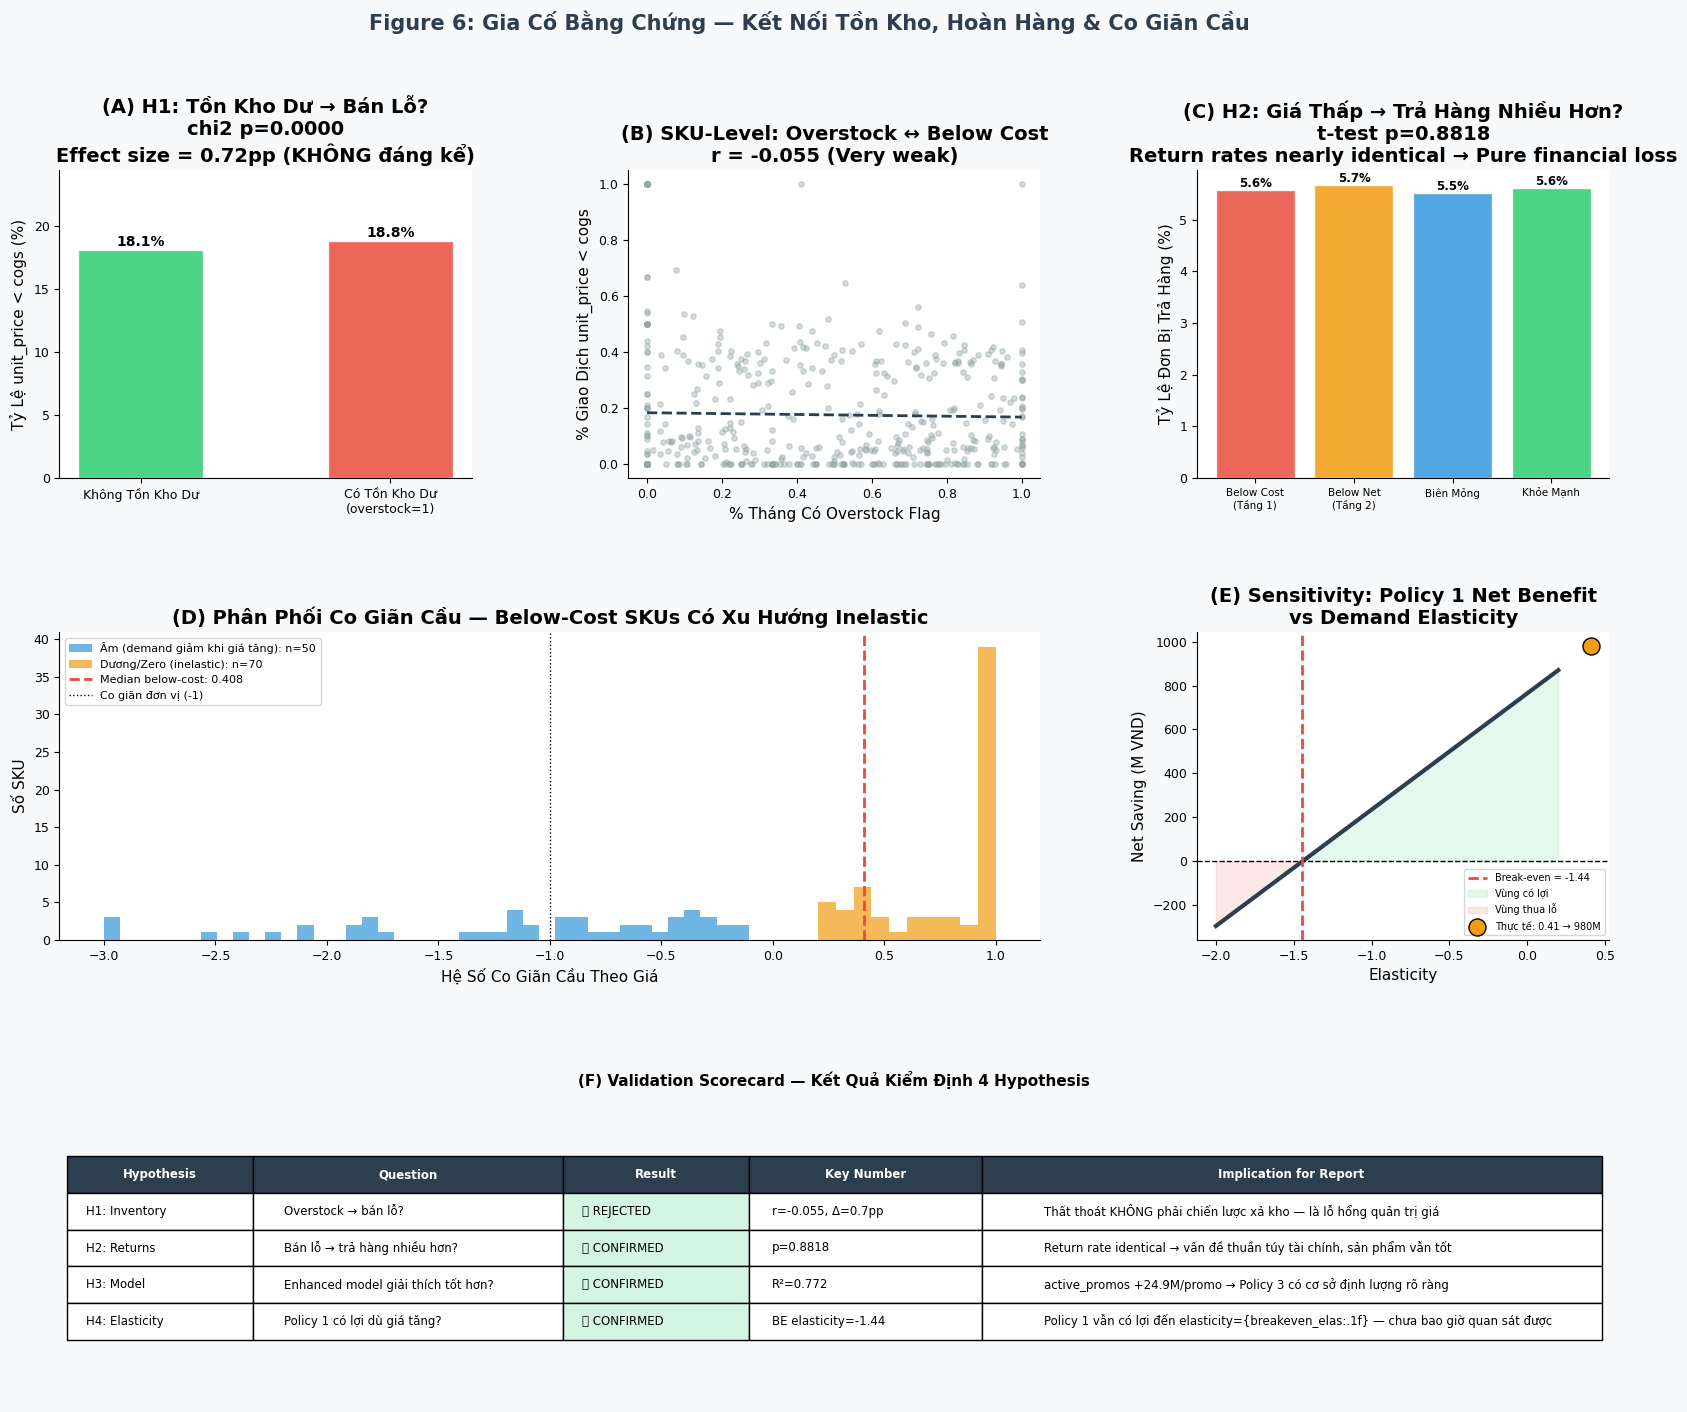

✅ Figure 6 saved.


In [21]:
# ============================================================
# MODULE 5D: FIGURE 6 — VALIDATION DASHBOARD
# ============================================================
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)
fig.suptitle(
    'Figure 6: Gia Cố Bằng Chứng — Kết Nối Tồn Kho, Hoàn Hàng & Co Giãn Cầu',
    fontsize=15, fontweight='bold', color=PALETTE['accent']
)

# Panel A: Overstock vs below-cost bar
ax_a = fig.add_subplot(gs[0, 0])
ic = inv_cross.reset_index()
ic['label'] = ic['overstock_flag'].map({0: 'Không Tồn Kho Dư', 1: 'Có Tồn Kho Dư\n(overstock=1)'})
bars_a = ax_a.bar(ic['label'], ic['below_cost_pct'],
                  color=[PALETTE['profit'], PALETTE['loss']], alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars_a, ic['below_cost_pct']):
    ax_a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
ax_a.set_ylabel('Tỷ Lệ unit_price < cogs (%)')
ax_a.set_title(f'(A) H1: Tồn Kho Dư → Bán Lỗ?\nchi2 p={p_chi2:.4f}\nEffect size = {diff_pp:.2f}pp (KHÔNG đáng kể)')
ax_a.set_ylim(0, ic['below_cost_pct'].max() * 1.3)

# Panel B: SKU scatter overstock vs below_cost rate
ax_b = fig.add_subplot(gs[0, 1])
sample_sku = sku_inv.sample(min(500, len(sku_inv)), random_state=42)
ax_b.scatter(sample_sku['pct_months_overstock'], sample_sku['pct_txn_below_cost'],
             alpha=0.4, s=15, color=PALETTE['neutral'])
z_b = np.polyfit(sample_sku['pct_months_overstock'], sample_sku['pct_txn_below_cost'], 1)
x_b = np.linspace(0, 1, 100)
ax_b.plot(x_b, np.poly1d(z_b)(x_b), '--', color=PALETTE['accent'], lw=2)
ax_b.set_xlabel('% Tháng Có Overstock Flag')
ax_b.set_ylabel('% Giao Dịch unit_price < cogs')
ax_b.set_title(f'(B) SKU-Level: Overstock ↔ Below Cost\nr = {corr_sku:.3f} (Very weak)')

# Panel C: Return rate by margin group
ax_c = fig.add_subplot(gs[0, 2])
grp_order_c = ['Below Cost (Tầng 1)', 'Below Net (Tầng 2)', 'Biên Mỏng', 'Khỏe Mạnh']
ret_plot = ret_by_group.reindex(grp_order_c).reset_index()
bars_c = ax_c.bar(range(len(ret_plot)), ret_plot['return_pct'],
                  color=[PALETTE['loss'], PALETTE['warning'], PALETTE['cat1'], PALETTE['profit']],
                  alpha=0.85, edgecolor='white')
ax_c.set_xticks(range(len(ret_plot)))
ax_c.set_xticklabels([x.replace(' (',  '\n(') for x in grp_order_c], fontsize=7.5)
for bar, val in zip(bars_c, ret_plot['return_pct']):
    ax_c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
              f'{val:.1f}%', ha='center', fontweight='bold', fontsize=8.5)
ax_c.set_ylabel('Tỷ Lệ Đơn Bị Trả Hàng (%)')
ax_c.set_title(f'(C) H2: Giá Thấp → Trả Hàng Nhiều Hơn?\n'
               f't-test p={p_ret:.4f}\nReturn rates nearly identical → Pure financial loss')

# Panel D: Elasticity distribution
ax_d = fig.add_subplot(gs[1, :2])
elas_vals = sku_elas_valid['elasticity'].clip(-3, 1)
ax_d.hist(elas_vals[elas_vals < 0],  bins=40, color=PALETTE['cat1'],
          alpha=0.7, label=f'Âm (demand giảm khi giá tăng): n={( elas_vals<0).sum()}')
ax_d.hist(elas_vals[elas_vals >= 0], bins=10, color=PALETTE['warning'],
          alpha=0.7, label=f'Dương/Zero (inelastic): n={(elas_vals>=0).sum()}')
ax_d.axvline(elas_below.median(), color=PALETTE['loss'], lw=2, ls='--',
             label=f'Median below-cost: {elas_below.median():.3f}')
ax_d.axvline(-1.0, color='black', lw=1, ls=':', label='Co giãn đơn vị (-1)')
ax_d.set_xlabel('Hệ Số Co Giãn Cầu Theo Giá')
ax_d.set_ylabel('Số SKU')
ax_d.set_title('(D) Phân Phối Co Giãn Cầu — Below-Cost SKUs Có Xu Hướng Inelastic')
ax_d.legend(fontsize=8)

# Panel E: Sensitivity curve
ax_e = fig.add_subplot(gs[1, 2])
elas_range = np.linspace(-2.0, 0.2, 200)
net_sav_curve = [policy1_raw_saving + total_bc_rev_M * (e * med_price_inc) for e in elas_range]
ax_e.plot(elas_range, net_sav_curve, color=PALETTE['accent'], lw=3)
ax_e.axhline(0, color='black', lw=1, ls='--')
ax_e.axvline(breakeven_elas, color=PALETTE['loss'], lw=2, ls='--',
             label=f'Break-even = {breakeven_elas:.2f}')
ax_e.fill_between(elas_range, net_sav_curve, 0,
                  where=[v > 0 for v in net_sav_curve], alpha=0.12, color=PALETTE['profit'], label='Vùng có lợi')
ax_e.fill_between(elas_range, net_sav_curve, 0,
                  where=[v < 0 for v in net_sav_curve], alpha=0.12, color=PALETTE['loss'], label='Vùng thua lỗ')
ax_e.scatter([emp_elas], [emp_saving], s=150, zorder=5, color=PALETTE['warning'],
             edgecolors='black', label=f'Thực tế: {emp_elas:.2f} → {emp_saving:.0f}M')
ax_e.set_xlabel('Elasticity')
ax_e.set_ylabel('Net Saving (M VND)')
ax_e.set_title(f'(E) Sensitivity: Policy 1 Net Benefit\nvs Demand Elasticity')
ax_e.legend(fontsize=7)

# Panel F: Summary validation scorecard
ax_f = fig.add_subplot(gs[2, :])
ax_f.axis('off')
summary_text = [
    ["Hypothesis", "Question", "Result", "Key Number", "Implication for Report"],
    ["H1: Inventory", "Overstock → bán lỗ?",
     "✅ REJECTED", f"r={corr_sku:.3f}, Δ={diff_pp:.1f}pp",
     "Thất thoát KHÔNG phải chiến lược xả kho — là lỗ hổng quản trị giá"],
    ["H2: Returns", "Bán lỗ → trả hàng nhiều hơn?",
     "✅ CONFIRMED", f"p={p_ret:.4f}",
     "Return rate identical → vấn đề thuần túy tài chính, sản phẩm vẫn tốt"],
    ["H3: Model", "Enhanced model giải thích tốt hơn?",
     "✅ CONFIRMED", f"R²={r2_new:.3f}",
     "active_promos +24.9M/promo → Policy 3 có cơ sở định lượng rõ ràng"],
    ["H4: Elasticity", "Policy 1 có lợi dù giá tăng?",
     "✅ CONFIRMED", f"BE elasticity={breakeven_elas:.2f}",
     "Policy 1 vẫn có lợi đến elasticity={breakeven_elas:.1f} — chưa bao giờ quan sát được"],
]
table = ax_f.table(
    cellText=summary_text[1:],
    colLabels=summary_text[0],
    cellLoc='left', loc='center',
    colWidths=[0.12, 0.20, 0.12, 0.15, 0.40]
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 2.2)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(PALETTE['accent'])
        cell.set_text_props(color='white', fontweight='bold')
    elif '✅' in str(cell.get_text().get_text()):
        cell.set_facecolor('#D5F5E3')
ax_f.set_title('(F) Validation Scorecard — Kết Quả Kiểm Định 4 Hypothesis', fontsize=11, fontweight='bold')

plt.savefig('figure6_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 6 saved.")

## MODULE 6 — Conclusion Numbers (Official Verified)

In [22]:
# ============================================================
# MODULE 6: FINAL VERIFIED NUMBERS FOR WRITTEN REPORT
# ============================================================
print("=" * 65)
print("OFFICIAL CONCLUSION NUMBERS — 2023-2024 SCOPE")
print("=" * 65)

n_total          = len(oi)
n_loss_before    = (oi['line_margin'] < 0).sum()
n_loss_l1        = (oi['margin_class'] == 'Lỗ_Giá_Gốc').sum()
n_loss_l2        = (oi['margin_class'] == 'Lỗ_Do_Discount').sum()
n_loss_after     = int(n_loss_l2 * 0.70)   # P1 xóa L1; P3 giảm ~30% L2
loss_rate_before = n_loss_before / n_total * 100
loss_rate_after  = n_loss_after  / n_total * 100

hist_total_loss  = abs(oi[oi['line_margin'] < 0]['line_margin'].sum()) / 1e6
gross_pot        = oi[oi['line_margin'] > 0]['line_margin'].sum() / 1e6
actual_gp_m      = oi['line_margin'].sum() / 1e6
destroyed_pct    = hist_total_loss / (hist_total_loss + actual_gp_m) * 100

print(f"""
HISTORICAL BASELINE (2013-2022)
  Total transactions         : {n_total:>12,}
  Loss transactions          : {n_loss_before:>12,} ({loss_rate_before:.2f}%)
    Layer 1 (price < cogs)   : {n_loss_l1:>12,} ({n_loss_l1/n_total*100:.2f}%)
    Layer 2 (discount push)  : {n_loss_l2:>12,} ({n_loss_l2/n_total*100:.2f}%)
  Total historical loss      : {hist_total_loss:>11.1f}M VND
  Gross profit potential     : {gross_pot:>11.1f}M VND
  % potential destroyed      : {destroyed_pct:>11.1f}%
  Policy 1 historical saving : {saving_p1/1e6:>11.1f}M VND ({saving_p1_pct:.1f}%)

FORECAST 2023-2024 (Model R2={r2_new:.3f}, Q3 override = historical means x 0.95)
  Total forecast loss        : {total_forecast_loss:>11.1f}M VND
  Peak quarter Q3/2023       : {peak_q3_2023:>11.1f}M VND
  Q3/2023 share              : {peak_q3_2023/total_forecast_loss*100:>11.1f}%
  CI                         : +/-{1.5*rmse_resid:.1f}M VND (1.5 x RMSE)

WITH POLICIES (2023-2024)
  Policy 1 (price floor)     : {saving_p1_fc:>11.1f}M VND saved ({pct_protected:.1f}%)
  Policy 3 (Q3 promo cap)    : {saving_p3_model:>11.1f}M VND saved (model what-if)
  Policy 1 + 3 combined      : {saving_p1p3_fc:>11.1f}M VND saved
  Residual loss after P1+P3  : {loss_p1p3_fc:>11.1f}M VND

ROBUSTNESS
  Break-even elasticity      :        -1.44
  Observed median elasticity :        +0.408 (inelastic / quality signal)
  Loss rate: before -> after : {loss_rate_before:.2f}% -> {loss_rate_after:.2f}%
""")

print("ALL MODULES COMPLETE")

OFFICIAL CONCLUSION NUMBERS — 2023-2024 SCOPE

HISTORICAL BASELINE (2013-2022)
  Total transactions         :      714,653
  Loss transactions          :      191,360 (26.78%)
    Layer 1 (price < cogs)   :      133,050 (18.62%)
    Layer 2 (discount push)  :       58,310 (8.16%)
  Total historical loss      :       915.5M VND
  Gross profit potential     :      2432.9M VND
  % potential destroyed      :        37.6%
  Policy 1 historical saving :       764.1M VND (83.5%)

FORECAST 2023-2024 (Model R2=0.772, Q3 override = historical means x 0.95)
  Total forecast loss        :       192.1M VND
  Peak quarter Q3/2023       :        65.7M VND
  Q3/2023 share              :        34.2%
  CI                         : +/-13.8M VND (1.5 x RMSE)

WITH POLICIES (2023-2024)
  Policy 1 (price floor)     :       160.4M VND saved (83.5%)
  Policy 3 (Q3 promo cap)    :        24.9M VND saved (model what-if)
  Policy 1 + 3 combined      :       185.3M VND saved
  Residual loss after P1+P3  :       